In [11]:
import yfinance as yf
import talib
import numpy as np
import pandas as pd
import vectorbt as vbt
import warnings
from scipy import stats
import matplotlib.pyplot as plt
from datetime import datetime
from joblib import Parallel, delayed
import time
import os

In [ ]:
# DOWNLOAD STOCK DATA USING YFINANCE

# Configuration - Change these variables as needed
TICKER = 'QQQ'  # Any ticker symbol (e.g., 'AAPL', 'MSFT', 'GOOGL')
START_DATE = '2018-01-01'  # Any start date in YYYY-MM-DD format

# Download data from start date onwards
stock_data = yf.download(TICKER, start=START_DATE, interval='1d')

if not stock_data.empty:
    print(f"Successfully downloaded {len(stock_data)} records for {TICKER} from {START_DATE}")
    print(f"Data range: {stock_data.index.min().date()} to {stock_data.index.max().date()}")
else:
    print(f"Failed to download {TICKER} data from yfinance")

# Display the downloaded data
stock_data


[*********************100%***********************]  1 of 1 completed

Successfully downloaded 2099 records for QQQ from 2018-01-01
Data range: 2018-01-02 to 2026-05-08


Price,Close,High,Low,Open,Volume
Ticker,QQQ,QQQ,QQQ,QQQ,QQQ
Date,,,,,
2018-01-02,150.222137,150.260044,148.023157,148.392811,32573300
2018-01-03,151.681778,151.814474,150.335856,150.364290,29383600
2018-01-04,151.947205,152.402161,151.729207,152.203124,24776100
2018-01-05,153.473175,153.577437,152.383172,152.667525,26992300
2018-01-08,154.070358,154.146187,153.416351,153.473218,23159100
...,...,...,...,...,...
2026-05-04,672.880005,676.729980,668.900024,674.659973,34542000
2026-05-05,681.609985,682.770020,677.510010,677.960022,37101100


In [ ]:
# TECHNICAL ANALYSIS INDICATORS USING TA-LIB

# Make sure stock_data is available from the previous cell
if "stock_data" not in locals():
    raise ValueError("Please run the stock data download cell first")

# Extract OHLCV data (handling multi-level columns from yfinance)
if isinstance(stock_data.columns, pd.MultiIndex):
    close = stock_data[("Close", TICKER)].to_numpy(dtype=np.float64)
    high = stock_data[("High", TICKER)].to_numpy(dtype=np.float64)
    low = stock_data[("Low", TICKER)].to_numpy(dtype=np.float64)
    open_ = stock_data[("Open", TICKER)].to_numpy(dtype=np.float64)
    volume = stock_data[("Volume", TICKER)].to_numpy(dtype=np.float64)
else:
    close = stock_data["Close"].to_numpy(dtype=np.float64)
    high = stock_data["High"].to_numpy(dtype=np.float64)
    low = stock_data["Low"].to_numpy(dtype=np.float64)
    open_ = stock_data["Open"].to_numpy(dtype=np.float64)
    volume = stock_data["Volume"].to_numpy(dtype=np.float64)

print(f"Calculating technical indicators for {TICKER}...")

# Simple Moving Averages
sma_20 = talib.SMA(close, timeperiod=20)
sma_50 = talib.SMA(close, timeperiod=50)

# Exponential Moving Averages
ema_12 = talib.EMA(close, timeperiod=12)
ema_26 = talib.EMA(close, timeperiod=26)

# MACD
macd, macdsignal, macdhist = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)

# RSI
rsi = talib.RSI(close, timeperiod=14)

# Stochastic RSI
stochrsi_k, stochrsi_d = talib.STOCHRSI(close, timeperiod=14, fastk_period=3, fastd_period=3, fastd_matype=0)

# VWAP (manual calculation)
typical_price = (high + low + close) / 3
price_volume = typical_price * volume
cumulative_price_volume = np.cumsum(price_volume)
cumulative_volume = np.cumsum(volume)
vwap = cumulative_price_volume / cumulative_volume

# Schaff Trend Cycle
cycle_period = 10
macd_cycle = talib.EMA(macd, timeperiod=cycle_period)
macd_smooth = talib.EMA(macd_cycle, timeperiod=cycle_period)
highest_macd = talib.MAX(macd_smooth, timeperiod=cycle_period)
lowest_macd = talib.MIN(macd_smooth, timeperiod=cycle_period)
stc_k = 100 * ((macd_smooth - lowest_macd) / (highest_macd - lowest_macd + 1e-10))
stc_d = talib.SMA(stc_k, timeperiod=3)

# On Balance Volume
obv = pd.Series(talib.OBV(close, volume))
obv_high = obv.shift(1).rolling(20).max()
obv_low = obv.shift(1).rolling(20).min()
obv_signal = (obv - obv_low) / (obv_high - obv_low + 1e-10)

# Create indicators dataframe
indicators_df = pd.DataFrame({
    "Date": stock_data.index,
    "Close": close,
    "SMA_20": sma_20,
    "SMA_50": sma_50,
    "EMA_12": ema_12,
    "EMA_26": ema_26,
    "MACD": macd,
    "MACD_Signal": macdsignal,
    "MACD_Hist": macdhist,
    "RSI": rsi,
    "StochRSI_K": stochrsi_k,
    "StochRSI_D": stochrsi_d,
    "VWAP": vwap,
    "STC_K": stc_k,
    "STC_D": stc_d,
    "OBV": obv,
    "OBV_High": obv_high,
    "OBV_Low": obv_low,
    "OBV_Signal": obv_signal
})

print("All technical indicators calculated!")
print(f"Data shape: {indicators_df.shape}")
indicators_df.tail(5)

Calculating technical indicators for QQQ...
All technical indicators calculated!
Data shape: (2099, 19)


,Date,Close,SMA_20,SMA_50,EMA_12,EMA_26,MACD,MACD_Signal,MACD_Hist,RSI,StochRSI_K,StochRSI_D,VWAP,STC_K,STC_D,OBV,OBV_High,OBV_Low,OBV_Signal
2094,2026-05-04,672.880005,642.414999,613.639463,656.964798,638.493044,18.471755,16.200092,2.271662,73.700932,42.102667,80.700889,336.903024,100.0,100.0,3.220904e+09,3.255446e+09,2.765530e+09,0.929494
2095,2026-05-05,681.609985,647.065997,615.258611,660.756366,641.686891,19.069474,16.773969,2.295506,76.459755,100.000000,80.700889,337.031828,100.0,100.0,3.258006e+09,3.255446e+09,2.815478e+09,1.005817
2096,2026-05-06,695.770020,651.549997,617.031921,666.143082,645.693049,20.450033,17.509181,2.940851,80.105259,100.000000,80.700889,337.171089,100.0,100.0,3.296784e+09,3.258006e+09,2.878564e+09,1.102199
2097,2026-05-07,694.940002,655.787497,618.612654,670.573377,649.340971,21.232406,18.253826,2.978579,79.329744,78.726816,92.908939,337.329615,100.0,100.0,3.253005e+09,3.296784e+09,2.916401e+09,0.884908
2098,2026-05-08,711.229980,660.795496,620.667798,676.828239,653.925343,22.902897,19.183640,3.719256,82.840843,100.000000,92.908939,337.494377,100.0,100.0,3.297151e+09,3.296784e+09,2.950440e+09,1.001060


In [ ]:
# PREPARE PRICE SERIES

warnings.filterwarnings("ignore", message="Degrees of freedom <= 0 for slice", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="invalid value encountered in scalar divide", category=RuntimeWarning)

# Expect stock_data and TICKER already exist
def select_series(df, ticker, col):
    if isinstance(df.columns, pd.MultiIndex):
        if (col, ticker) in df.columns:
            s = df[(col, ticker)]
        else:
            cols = [c for c in df.columns if col in str(c)]
            if not cols:
                raise KeyError(f"{col} not found")
            s = df[cols[0]]
    else:
        s = df[col]
    return s.astype(float).squeeze()

close = select_series(stock_data, TICKER, 'Close')
close.name = 'price'
volume = select_series(stock_data, TICKER, 'Volume')
volume.name = 'volume'

# Simple split
TRAIN_RATIO = 0.50 
split_idx = int(len(close) * TRAIN_RATIO)
train_close = close.iloc[:split_idx].copy()
val_close   = close.iloc[split_idx:].copy()
train_volume = volume.iloc[:split_idx].copy()
val_volume = volume.iloc[split_idx:].copy()

print(f"Data ready: train={train_close.index[0].date()} → {train_close.index[-1].date()} | val={val_close.index[0].date()} → {val_close.index[-1].date()}")

# Auto-detect market calendar from actual bars/year in the data
_calendar_days = max((close.index[-1] - close.index[0]).days, 1)
_bars_per_year = len(close) / (_calendar_days / 365.25)
IS_24_7_MARKET = _bars_per_year > 330
TRADING_DAYS_PER_YEAR = 365 if IS_24_7_MARKET else 252
YEAR_FREQ = f"{TRADING_DAYS_PER_YEAR}D"
FREQ = "1D"


def sample_years(price_series):
    return max(len(price_series) / TRADING_DAYS_PER_YEAR, 1e-9)


market_label = 'crypto (365-day)' if IS_24_7_MARKET else 'stock (252-day)'
print(f"Bars/year: {_bars_per_year:.0f} → FREQ='{FREQ}', YEAR_FREQ='{YEAR_FREQ}' ({market_label})")

Data ready: train=2018-01-02 → 2022-03-02 | val=2022-03-03 → 2026-05-08
Bars/year: 252 → FREQ='1D', YEAR_FREQ='252D' (stock (252-day))


TI GRID SEARCH - TRAINING SET
----------------------------------------------

This section performs a comprehensive grid search optimization using only the **training data**.

The goal is to find the optimal params combination of the TI that maximizes the Sharpe ratio on unseen data.

In [ ]:
# 🎯 SELECT YOUR INDICATOR HERE
SELECTED_INDICATOR_NAME = 'OBV'  # ← Change this to 'TEMA', 'MACD', 'STC', 'RSI' or 'OBV'

### Add TIs, their calculations and signal strategies, grid range here

In [ ]:
# GENERIC TECHNICAL INDICATOR REGISTRY & DYNAMIC PARAMETER GENERATION

import itertools
from typing import Dict, List, Tuple, Callable, Any, Union
from dataclasses import dataclass
import pandas as pd
import numpy as np

# ============================================================================
# STEP 1: DEFINE TECHNICAL INDICATOR METADATA REGISTRY
# ============================================================================

@dataclass
class IndicatorParam:
    """Metadata for a single parameter of a technical indicator"""
    name: str                    # e.g., 'fast_period', 'threshold'
    min_val: Union[int, float]       # Minimum value
    max_val: Union[int, float]       # Maximum value
    step: Union[int, float]          # Step size for range generation
    param_type: type = int  # Add this field - specify int or float
    constraint: Callable = None # Optional: lambda to validate params (e.g., fast < slow)
    
    def generate_range(self) -> List:
        """Generate list of values for this parameter"""
        if isinstance(self.min_val, int):
            return list(range(self.min_val, self.max_val + 1, self.step))
        else:
            return np.arange(self.min_val, self.max_val, self.step).tolist()


@dataclass
class TechnicalIndicator:
    """Complete definition of a technical indicator"""
    name: str                               # indicator name
    params: Dict[str, IndicatorParam]      # {param_name: IndicatorParam}
    calc_func: Callable                     # Function to calculate indicator
    signal_func: Callable                   # Function to generate entry/exit signals
    description: str = ""
    

# ============================================================================
# STEP 2: DEFINE INDICATOR CALCULATION & SIGNAL FUNCTIONS
# ============================================================================

def calc_triple_ema_cached(close_series: pd.Series, **kwargs) -> Dict[str, pd.Series]:
    """Use pre-computed cache instead of recalculating"""
    ema_cache = kwargs.get('ema_cache', None)
    if ema_cache is None:
        # Fallback for non-batch calls
        ema1 = pd.Series(vbt.MA.run(close_series, kwargs['ema1_period'], ewm=True).ma.values.flatten(), 
                         index=close_series.index)
        ema2 = pd.Series(vbt.MA.run(close_series, kwargs['ema2_period'], ewm=True).ma.values.flatten(), 
                         index=close_series.index)
        ema3 = pd.Series(vbt.MA.run(close_series, kwargs['ema3_period'], ewm=True).ma.values.flatten(), 
                         index=close_series.index)
    else:
        # Extract from cache (pre-computed)
        ema1 = pd.Series(ema_cache.ma[kwargs['ema1_period']].values.flatten(), index=close_series.index)
        ema2 = pd.Series(ema_cache.ma[kwargs['ema2_period']].values.flatten(), index=close_series.index)
        ema3 = pd.Series(ema_cache.ma[kwargs['ema3_period']].values.flatten(), index=close_series.index)
    
    return {'ema1': ema1, 'ema2': ema2, 'ema3': ema3}


def signal_triple_ema(indicators: Dict[str, pd.Series], **kwargs) -> Tuple[pd.Series, pd.Series]:
    """
    Triple EMA crossover signals: Buy when any EMA crosses above another
    
    Args:
        indicators: dict with 'ema1', 'ema2', 'ema3'
    
    Returns:
        (entries, exits) as boolean Series
    """
    ema1, ema2, ema3 = indicators['ema1'], indicators['ema2'], indicators['ema3']
    
    # Entry: Any EMA crosses above another
    entries_raw = (
        ema1.vbt.crossed_above(ema2) |
        ema1.vbt.crossed_above(ema3) |
        ema2.vbt.crossed_above(ema3)
    )
    
    # Exit: Any EMA crosses below another
    exits_raw = (
        ema1.vbt.crossed_below(ema2) |
        ema1.vbt.crossed_below(ema3) |
        ema2.vbt.crossed_below(ema3)
    )
    
    # Fix lookahead bias: shift by 1 bar
    entries = pd.Series(
        np.where(entries_raw.shift(1).isna(), False, entries_raw.shift(1)),
        index=ema1.index, dtype=bool
    )
    exits = pd.Series(
        np.where(exits_raw.shift(1).isna(), False, exits_raw.shift(1)),
        index=ema1.index, dtype=bool
    )
    
    return entries, exits


def calc_macd(close_series: pd.Series, **kwargs) -> Dict[str, pd.Series]:
    """
    Calculate MACD indicators
    
    Args:
        close_series: Close price series
        fast_period, slow_period, signal_period: MACD periods
    
    Returns:
        dict with keys: 'macd', 'signal', 'histogram'
    """
    fast_period = kwargs['fast_period']
    slow_period = kwargs['slow_period']
    signal_period = kwargs['signal_period']
    
    macd_val, signal_val, hist_val = talib.MACD(
        close_series.values,
        fastperiod=fast_period,
        slowperiod=slow_period,
        signalperiod=signal_period
    )
    
    return {
        'macd': pd.Series(macd_val, index=close_series.index),
        'signal': pd.Series(signal_val, index=close_series.index),
        'histogram': pd.Series(hist_val, index=close_series.index)
    }


def signal_macd(indicators: Dict[str, pd.Series], **kwargs) -> Tuple[pd.Series, pd.Series]:
    """
    MACD crossover signals: Buy when MACD crosses above signal line
    
    Args:
        indicators: dict with 'macd', 'signal'
    
    Returns:
        (entries, exits) as boolean Series
    """
    macd_line = indicators['macd']
    signal_line = indicators['signal']
    
    # Entry: MACD crosses above signal
    entries_raw = macd_line.vbt.crossed_above(signal_line)
    
    # Exit: MACD crosses below signal
    exits_raw = macd_line.vbt.crossed_below(signal_line)
    
    # Fix lookahead bias
    entries = pd.Series(
        np.where(entries_raw.shift(1).isna(), False, entries_raw.shift(1)),
        index=macd_line.index, dtype=bool
    )
    exits = pd.Series(
        np.where(exits_raw.shift(1).isna(), False, exits_raw.shift(1)),
        index=macd_line.index, dtype=bool
    )
    
    return entries, exits


def calc_stc(close_series: pd.Series, **kwargs) -> Dict[str, pd.Series]:
    """
    Calculate Schaff Trend Cycle (STC)
    
    Args:
        close_series: Close price series
        macd_fast, macd_slow, stc_cycle, stc_signal: STC parameters
    
    Returns:
        dict with keys: 'stc_k', 'stc_d'
    """
    macd_fast = kwargs['macd_fast']
    macd_slow = kwargs['macd_slow']
    stc_cycle = kwargs['stc_cycle']
    stc_signal = kwargs['stc_signal']
    
    # Calculate MACD
    macd_val, _, _ = talib.MACD(close_series.values, macd_fast, macd_slow, 1)
    
    # Smooth MACD
    macd_cycle = talib.EMA(macd_val, stc_cycle)
    macd_smooth = talib.EMA(macd_cycle, stc_cycle)
    
    # Normalize to 0-100
    highest_macd = talib.MAX(macd_smooth, stc_cycle)
    lowest_macd = talib.MIN(macd_smooth, stc_cycle)
    stc_k_val = 100 * ((macd_smooth - lowest_macd) / (highest_macd - lowest_macd + 1e-10))
    stc_d_val = talib.SMA(stc_k_val, stc_signal)
    
    return {
        'stc_k': pd.Series(stc_k_val, index=close_series.index),
        'stc_d': pd.Series(stc_d_val, index=close_series.index)
    }


def signal_stc(indicators: Dict[str, pd.Series], **kwargs) -> Tuple[pd.Series, pd.Series]:
    """
    STC crossover signals: Buy when STC_K crosses above STC_D
    
    Args:
        indicators: dict with 'stc_k', 'stc_d'
        kwargs: Additional parameters (buy_threshold, sell_threshold)
    
    Returns:
        (entries, exits) as boolean Series
    """
    stc_k = indicators['stc_k']
    stc_d = indicators['stc_d']
    
    entries_raw = stc_k.vbt.crossed_above(stc_d)
    exits_raw = stc_k.vbt.crossed_below(stc_d)
    
    entries = pd.Series(
        np.where(entries_raw.shift(1).isna(), False, entries_raw.shift(1)),
        index=stc_k.index, dtype=bool
    )
    exits = pd.Series(
        np.where(exits_raw.shift(1).isna(), False, exits_raw.shift(1)),
        index=stc_k.index, dtype=bool
    )
    
    return entries, exits


def calc_rsi(close_series: pd.Series, **kwargs) -> Dict[str, pd.Series]:
    """
    Calculate RSI indicator
    
    Args:
        close_series: Close price series
        period: RSI period
    
    Returns:
        dict with key: 'rsi'
    """
    period = kwargs['period']
    rsi_val = talib.RSI(close_series.values, timeperiod=period)
    
    return {'rsi': pd.Series(rsi_val, index=close_series.index)}


def signal_rsi(indicators: Dict[str, pd.Series], **kwargs) -> Tuple[pd.Series, pd.Series]:
    """
    RSI threshold signals: Buy when RSI < oversold threshold, Sell when RSI > overbought
    
    Args:
        indicators: dict with 'rsi'
        kwargs: Additional parameters (oversold, overbought)
    
    Returns:
        (entries, exits) as boolean Series
    """
    rsi = indicators['rsi']
    
    # Typical thresholds: oversold=30, overbought=70
    oversold = kwargs['oversold']
    overbought = kwargs['overbought']
    
    entries = pd.Series(rsi < oversold, index=rsi.index, dtype=bool)
    exits = pd.Series(rsi > overbought, index=rsi.index, dtype=bool)
    
    return entries, exits

def calc_obv_signal(close_series: pd.Series, volume_series: pd.Series, **kwargs) -> Dict[str, pd.Series]:
    """
    Calculate OBV and its normalized signal
    
    Args:
        close_series: Close price series
        volume_series: Volume series
    
    Returns:
        dict with keys: 'obv', 'obv_high', 'obv_low', 'obv_signal'
    """
    obv = pd.Series(talib.OBV(close_series.values, volume_series.values), index=close_series.index)
    obv_signal_period = int(kwargs['obv_signal_period'])
    obv_high = obv.shift(1).rolling(obv_signal_period).max()
    obv_low = obv.shift(1).rolling(obv_signal_period).min()
    obv_signal = (obv - obv_low) / (obv_high - obv_low + 1e-10)
    
    return {
        'obv_signal': obv_signal
    }

def signal_obv(indicators: Dict[str, pd.Series], **kwargs) -> Tuple[pd.Series, pd.Series]:
    """
    OBV signal: Buy when OBV_Signal crosses above upper threshold, Sell when it crosses below lower threshold
    
    Args:
        indicators: dict with 'obv_signal'
    
    Returns:
        (entries, exits) as boolean Series
    """
    obv_signal = indicators['obv_signal']

    buy_threshold = kwargs['buy_threshold']
    sell_threshold = kwargs['sell_threshold']
    
    entries_raw = obv_signal.vbt.crossed_above(buy_threshold)
    exits_raw = obv_signal.vbt.crossed_below(sell_threshold)
    
    entries = pd.Series(
        np.where(entries_raw.shift(1).isna(), False, entries_raw.shift(1)),
        index=obv_signal.index, dtype=bool
    )
    exits = pd.Series(
        np.where(exits_raw.shift(1).isna(), False, exits_raw.shift(1)),
        index=obv_signal.index, dtype=bool
    )
    
    return entries, exits

In [ ]:
# Grid Ranges Config

# ============================================================================
# STEP 3: REGISTER INDICATORS WITH THEIR METADATA
# ============================================================================

INDICATOR_REGISTRY: Dict[str, TechnicalIndicator] = {
    
    'TEMA': TechnicalIndicator(
        name='TEMA',
        params={
            'ema1_period': IndicatorParam('EMA1 (Fast)', 2, 8, 1),
            'ema2_period': IndicatorParam('EMA2 (Medium)', 20, 150, 3),
            'ema3_period': IndicatorParam('EMA3 (Slow)', 50, 220, 3),
        },
        calc_func=calc_triple_ema_cached,
        signal_func=signal_triple_ema,
        description="Triple Exponential Moving Average Crossover Strategy"
    ),
    
    'MACD': TechnicalIndicator(
        name='MACD',
        params={
            'fast_period': IndicatorParam('Fast Period', 2, 100, 2),
            'slow_period': IndicatorParam('Slow Period', 2, 100, 2),
            'signal_period': IndicatorParam('Signal Period', 2, 100, 2),
        },
        calc_func=calc_macd,
        signal_func=signal_macd,
        description="MACD Line vs Signal Line Crossover Strategy"
    ),
    
    'STC': TechnicalIndicator(
        name='STC',
        params={
            'macd_fast': IndicatorParam('MACD Fast', 8 , 30, 2),
            'macd_slow': IndicatorParam('MACD Slow', 20, 70, 3),
            'stc_cycle': IndicatorParam('STC Cycle', 5, 15, 1),
            'stc_signal': IndicatorParam('STC Signal', 2, 8, 1),
        },
        calc_func=calc_stc,
        signal_func=signal_stc,
        description="Schaff Trend Cycle Crossover Strategy"
    ),
    
    'RSI': TechnicalIndicator(
        name='RSI',
        params={
            'period': IndicatorParam('RSI Period', 10, 30, 2),
            'oversold': IndicatorParam('Oversold Threshold', 5, 40, 5),
            'overbought': IndicatorParam('Overbought Threshold', 60, 100, 5),
        },
        calc_func=calc_rsi,
        signal_func=signal_rsi,
        description="RSI Overbought/Oversold Threshold Strategy"
    ),

    'OBV': TechnicalIndicator(
        name='OBV',
        params={
            'obv_signal_period': IndicatorParam('OBV Signal Period', 4, 100, 2),
            'buy_threshold': IndicatorParam('Buy Threshold', 0.5, 1.55, 0.05, param_type=float),
            'sell_threshold': IndicatorParam('Sell Threshold', 0.0, 1.0, 0.05, param_type=float),
        },
        calc_func=calc_obv_signal,
        signal_func=signal_obv,
        description="On Balance Volume (OBV) Signal Strategy"
    ),
}


# ============================================================================
# STEP 4: DYNAMIC PARAMETER COMBINATION GENERATOR
# ============================================================================

class ParameterComboGenerator:
    """Generate all valid parameter combinations for an indicator"""
    
    def __init__(self, indicator: TechnicalIndicator):
        self.indicator = indicator
        self.param_names = list(indicator.params.keys())
    
    def generate_combinations(self) -> List[Dict[str, Any]]:
        """
        Generate all parameter combinations with constraints applied
        
        Returns:
            List of dicts: [{param_name: value, ...}, ...]
        """
        # Generate ranges for each parameter
        param_ranges = {}
        for param_name, param_meta in self.indicator.params.items():
            param_ranges[param_name] = param_meta.generate_range()
        
        # Generate all combinations
        combinations = []
        for combo_values in itertools.product(*param_ranges.values()):
            combo_dict = dict(zip(self.param_names, combo_values))
            
            # Apply any constraints
            if self._check_constraints(combo_dict):
                combinations.append(combo_dict)
        
        return combinations
    
    def _check_constraints(self, combo: Dict[str, Any]) -> bool:
        """Check if combination satisfies parameter constraints"""
        
        # TEMA: ema1 < ema2 AND ema1 < ema3 (allow ema2 and ema3 to oscillate)
        if self.indicator.name == 'TEMA':
            ema1 = combo['ema1_period']
            ema2 = combo['ema2_period']
            ema3 = combo['ema3_period']
            return ema1 < ema2 and ema1 < ema3
        
        # MACD: fast < slow
        if self.indicator.name == 'MACD':
            return combo['fast_period'] < combo['slow_period']
        
        # STC: fast < slow
        if self.indicator.name == 'STC':
            return combo['macd_fast'] < combo['macd_slow']
        
        if self.indicator.name == 'RSI':
            return combo['oversold'] < combo['overbought']
        
        if self.indicator.name == 'OBV':
            return combo['sell_threshold'] < combo['buy_threshold']
        
        return True


# ============================================================================
# STEP 5: MAIN SELECTION & INITIALIZATION
# ============================================================================

if SELECTED_INDICATOR_NAME not in INDICATOR_REGISTRY:
    raise ValueError(
        f"Indicator '{SELECTED_INDICATOR_NAME}' not found. "
        f"Available: {list(INDICATOR_REGISTRY.keys())}"
    )

# Load the selected indicator
INDICATOR = INDICATOR_REGISTRY[SELECTED_INDICATOR_NAME]

print("=" * 80)
print(f"🎯 TECHNICAL INDICATOR FRAMEWORK")
print("=" * 80)
print(f"Selected Indicator: {INDICATOR.name}")
print(f"Description: {INDICATOR.description}")
print()

# Display parameters
print(f"Parameters ({len(INDICATOR.params)}):")
for param_name, param_meta in INDICATOR.params.items():
    param_range = param_meta.generate_range()
    print(f"  • {param_meta.name}")
    print(f"    Range: {min(param_range)} - {max(param_range)}, "
          f"Step: {param_meta.step}, Count: {len(param_range)}")
print()

# Generate combinations
print("Generating parameter combinations...")
combo_gen = ParameterComboGenerator(INDICATOR)
indicator_combinations = combo_gen.generate_combinations()

print(f"✅ Generated {len(indicator_combinations)} valid combinations")

🎯 TECHNICAL INDICATOR FRAMEWORK
Selected Indicator: OBV
Description: On Balance Volume (OBV) Signal Strategy

Parameters (3):
  • OBV Signal Period
    Range: 4 - 100, Step: 2, Count: 49
  • Buy Threshold
    Range: 0.5 - 1.4999999999999998, Step: 0.1, Count: 11
  • Sell Threshold
    Range: 0.0 - 0.9, Step: 0.1, Count: 10

Generating parameter combinations...
✅ Generated 4655 valid combinations


### Run all the way down after selecting TI to be tested

In [ ]:
# GENERIC GRID SEARCH OPTIMIZATION - TRAINING SET (VECTORIZED & BATCHED)

print("=" * 80)
print("INITIATING VECTORIZED GRID SEARCH OPTIMIZATION")
print("=" * 80)
print(f"Testing Strategy: {INDICATOR.description}")
print(f"Indicator: {INDICATOR.name}")
print(f"Training Period: {train_close.index[0].date()} → {train_close.index[-1].date()}")
print(f"Market Regime: {market_label}")
print(f"Annualization Basis: {TRADING_DAYS_PER_YEAR} bars/year ({YEAR_FREQ})")
print(f"Initial Capital: $100,000")
print(f"Transaction Costs: 0.05% per trade (fees + slippage)")
print(f"Optimization Metric: Sharpe Ratio (risk-adjusted returns)")
print("=" * 80)

# Configuration
BATCH_SIZE = 1000
MIN_TRADES_PER_YEAR = 2
KWARGS = {}  # Additional kwargs for signal generation if needed
total_combinations = len(indicator_combinations)
train_years = sample_years(train_close)
results_df = None

print(f"\nParameters: {', '.join(INDICATOR.params.keys())}")
print(f"Total combinations to test: {total_combinations}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Minimum trade frequency filter: {MIN_TRADES_PER_YEAR}/year")
print(f"Using vectorized computation for maximum speed\n")

# ============================================================================
# PRE-COMPUTE CACHE (For indicators with computationally expensive components)
# ============================================================================

# For TEMA: cache all unique EMA periods
if INDICATOR.name == 'TEMA':
    all_ema_periods = sorted(list(set([
        p for combo in indicator_combinations 
        for key, p in combo.items() if 'period' in key
    ])))
    print(f"Pre-computing {len(all_ema_periods)} unique EMAs: {all_ema_periods}")
    ema_cache = vbt.MA.run(train_close, window=all_ema_periods, ewm=True)
    print("✓ All EMAs cached\n")
    
    def get_ema_from_cache(period):
        """Helper to extract EMA from pre-computed cache"""
        return pd.Series(
            ema_cache.ma[period].values.flatten(),
            index=train_close.index
        )
    
    # KWARGS['ema_cache'] = ema_cache

# For STC: pre-compute basic MACD values (optional - can skip)
elif INDICATOR.name == 'STC':
    print("Pre-computing STC helper values...")
    print("✓ STC setup ready\n")

elif INDICATOR.name == 'OBV':
    KWARGS['volume_series'] = train_volume

# For MACD and RSI: minimal pre-computation needed
else:
    print(f"Minimal pre-computation for {INDICATOR.name}\n")

# ============================================================================
# MAIN GRID SEARCH LOOP - BATCHED & VECTORIZED
# ============================================================================

grid_search_results = []
successful_tests = 0
failed_tests = 0

print("Starting batched grid search...\n")

for batch_start in range(0, total_combinations, BATCH_SIZE):
    batch_end = min(batch_start + BATCH_SIZE, total_combinations)
    batch_combos = indicator_combinations[batch_start:batch_end]
    batch_size = len(batch_combos)
    batch_num = (batch_start // BATCH_SIZE) + 1
    total_batches = (total_combinations + BATCH_SIZE - 1) // BATCH_SIZE
    
    print(f"Batch {batch_num}/{total_batches}: Combinations {batch_start+1} to {batch_end}")
    
    # Build signal matrices for this batch
    batch_entries = []
    batch_exits = []
    failed_combos_in_batch = []
    
    # ========================================================================
    # SIGNAL GENERATION FOR BATCH
    # ========================================================================
    
    for combo_idx, combo in enumerate(batch_combos):
        try:
            # Calculate indicator for this combination
            indicators = INDICATOR.calc_func(train_close, **KWARGS, **combo)
            
            # Generate signals
            entries_raw, exits_raw = INDICATOR.signal_func(indicators, **combo)
            
            # Fix lookahead bias: shift by 1 bar (already done in signal_func for most)
            # Double-check in case signal_func didn't do it
            if not isinstance(entries_raw.iloc[0] if isinstance(entries_raw, pd.Series) else entries_raw[0], (bool, np.bool_)):
                entries_raw = entries_raw.astype(bool)
            if not isinstance(exits_raw.iloc[0] if isinstance(exits_raw, pd.Series) else exits_raw[0], (bool, np.bool_)):
                exits_raw = exits_raw.astype(bool)
            
            batch_entries.append(entries_raw)
            batch_exits.append(exits_raw)
            
        except Exception as e:
            print(f"  ⚠️  Failed to generate signals for combo {combo_idx+1}/{batch_size} in batch {batch_num}: {e}")
            # Log failed combination but continue
            batch_entries.append(pd.Series(False, index=train_close.index, dtype=bool))
            batch_exits.append(pd.Series(False, index=train_close.index, dtype=bool))
            failed_combos_in_batch.append((combo_idx, str(e)[:50]))
            failed_tests += 1
    
    # Convert to DataFrames for vectorized backtesting
    try:
        entries_df = pd.DataFrame([e.values for e in batch_entries]).T
        exits_df = pd.DataFrame([e.values for e in batch_exits]).T
        
        print(f"  Running vectorized backtest on {batch_size} combinations...")
        
        # ====================================================================
        # VECTORIZED BACKTEST FOR ENTIRE BATCH
        # ====================================================================
        
        portfolios = vbt.Portfolio.from_signals(
            close=train_close,
            entries=entries_df,
            exits=exits_df,
            init_cash=100_000,
            fees=0.0005,
            slippage=0.0005,
            freq=FREQ
        )
        
        # Extract batch metrics (vectorized)
        total_returns = portfolios.total_return()
        annualized_returns = portfolios.annualized_return(freq=FREQ, year_freq=YEAR_FREQ)
        max_drawdowns = portfolios.max_drawdown()
        volatilities = portfolios.annualized_volatility(freq=FREQ, year_freq=YEAR_FREQ)
        sharpe_ratios = portfolios.sharpe_ratio(freq=FREQ, year_freq=YEAR_FREQ)
        sortino_ratios = portfolios.sortino_ratio(freq=FREQ, year_freq=YEAR_FREQ)
        
        # ====================================================================
        # PROCESS EACH RESULT IN BATCH
        # ====================================================================
        
        for result_idx, (combo_idx, combo) in enumerate(enumerate(batch_combos)):
            # Skip if this combination failed during signal generation
            if result_idx in [fc[0] for fc in failed_combos_in_batch]:
                continue
            
            try:
                # Extract scalar values for this combination
                total_return = float(
                    total_returns.iloc[result_idx] 
                    if hasattr(total_returns, 'iloc') 
                    else total_returns
                )
                annualized_return = float(
                    annualized_returns.iloc[result_idx] 
                    if hasattr(annualized_returns, 'iloc') 
                    else annualized_returns
                )
                max_drawdown = float(
                    max_drawdowns.iloc[result_idx] 
                    if hasattr(max_drawdowns, 'iloc') 
                    else max_drawdowns
                )
                volatility = float(
                    volatilities.iloc[result_idx] 
                    if hasattr(volatilities, 'iloc') 
                    else volatilities
                )
                sharpe_ratio = float(
                    sharpe_ratios.iloc[result_idx] 
                    if hasattr(sharpe_ratios, 'iloc') 
                    else sharpe_ratios
                )
                sortino_ratio = float(
                    sortino_ratios.iloc[result_idx] 
                    if hasattr(sortino_ratios, 'iloc') 
                    else sortino_ratios
                )
                
                # ============================================================
                # TRADE-LEVEL METRICS
                # ============================================================
                
                trades = portfolios[result_idx].trades if batch_size > 1 else portfolios.trades
                total_trades = len(trades)
                
                # Trades-per-year filter (market-aware)
                trades_per_year = total_trades / train_years if train_years > 0 else 0
                
                if trades_per_year < MIN_TRADES_PER_YEAR:
                    continue
                
                # Initialize trade statistics
                win_rate_pct = np.nan
                profit_factor = np.nan
                expectancy = 0.0
                avg_win_amount = 0.0
                avg_loss_amount = 0.0
                winning_streak = np.nan
                losing_streak = np.nan
                
                if total_trades > 0:
                    tr = (
                        trades.returns.values 
                        if hasattr(trades.returns, 'values') 
                        else np.array(trades.returns)
                    )
                    
                    if tr.size > 0:
                        pos = tr[tr > 0]
                        neg = tr[tr < 0]
                        win_rate_pct = (len(pos) / len(tr)) * 100.0 if len(tr) > 0 else np.nan
                        gains = pos.sum() if len(pos) else 0.0
                        losses = abs(neg.sum()) if len(neg) else 0.0
                        profit_factor = gains / losses if losses > 0 else np.inf
                        expectancy = float(tr.mean())
                        avg_win_amount = float(pos.mean()) if len(pos) else 0.0
                        avg_loss_amount = float(abs(neg.mean())) if len(neg) else 0.0
                        
                        try:
                            ws = trades.winning_streak
                            ls = trades.losing_streak
                            winning_streak = int(ws[result_idx] if batch_size > 1 else ws)
                            losing_streak = int(ls[result_idx] if batch_size > 1 else ls)
                        except:
                            pass
                
                # ============================================================
                # ADDITIONAL METRICS
                # ============================================================
                
                # Ulcer Index
                returns = (
                    portfolios.returns().iloc[:, result_idx] 
                    if batch_size > 1 
                    else portfolios.returns()
                )
                cum = (1 + returns).cumprod()
                peak = cum.cummax()
                dd = (cum - peak) / peak
                ulcer_index = float(np.sqrt((dd.pow(2)).mean())) if len(dd) > 0 else np.nan
                
                payoff_ratio = (
                    (avg_win_amount / avg_loss_amount) 
                    if avg_loss_amount not in (0.0, np.nan) 
                    else np.inf
                )
                
                # ============================================================
                # STORE RESULT
                # ============================================================
                
                result_dict = {
                    # Strategy parameters (dynamic based on indicator)
                    **combo,
                    
                    # Return metrics
                    "total_return": total_return,
                    "annualized_return": annualized_return,
                    "total_profit": total_return,  # normalized by initial capital
                    
                    # Risk-adjusted metrics
                    "sharpe_ratio": sharpe_ratio,
                    "sortino_ratio": sortino_ratio,
                    "calmar_ratio": annualized_return / abs(max_drawdown) if max_drawdown != 0 else np.inf,
                    "omega_ratio": np.nan,
                    "information_ratio": np.nan,
                    "tail_ratio": np.nan,
                    "deflated_sharpe_ratio": np.nan,
                    
                    # Risk metrics
                    "max_drawdown": max_drawdown,
                    "volatility": volatility,
                    "ulcer_index": ulcer_index,
                    
                    # Trade metrics
                    "total_trades": total_trades,
                    "trades_per_year": trades_per_year,
                    "win_rate": win_rate_pct,
                    "avg_win_amount": avg_win_amount,
                    "avg_loss_amount": avg_loss_amount,
                    "expectancy": expectancy,
                    "profit_factor": profit_factor,
                    "payoff_ratio": payoff_ratio,
                    "winning_streak": winning_streak,
                    "losing_streak": losing_streak,
                    "sqn": np.nan,
                    "recovery_factor": np.nan,
                    "gain_to_pain_ratio": np.nan,
                    "serenity_index": np.nan,
                }
                
                grid_search_results.append(result_dict)
                successful_tests += 1
                
            except Exception as e:
                failed_tests += 1
                continue
        
        print(f"  ✓ Batch complete")
        
    except Exception as e:
        print(f"  ⚠️ Batch failed: {str(e)[:100]}")
        failed_tests += batch_size

# ============================================================================
# GRID SEARCH COMPLETION SUMMARY
# ============================================================================

print("=" * 80)
print("VECTORIZED GRID SEARCH COMPLETED!")
print("=" * 80)
print(f"Total combinations attempted: {total_combinations}")
print(f"Successfully completed: {successful_tests}")
print(f"Failed or filtered: {failed_tests}")
print(f"Success rate: {(successful_tests/total_combinations)*100:.1f}%")
print(f"\n✓ Results stored in 'grid_search_results' ({len(grid_search_results)} entries)")

# ============================================================================
# CONVERT TO DATAFRAME & DISPLAY TOP PERFORMERS
# ============================================================================

if grid_search_results:
    results_df = pd.DataFrame(grid_search_results)
    
    print("\n" + "=" * 80)
    print(f"🏆 TOP 10 COMBINATIONS (by In-Sample Sharpe Ratio)")
    print("=" * 80)
    
    top_10 = results_df.nlargest(10, 'sharpe_ratio')
    
    # Create display columns dynamically
    param_cols = list(INDICATOR.params.keys())
    display_cols = param_cols + [
        'sharpe_ratio', 'total_return', 'annualized_return', 
        'max_drawdown', 'win_rate', 'profit_factor', 
        'total_trades', 'trades_per_year'
    ]
    
    display_df = top_10[display_cols].copy()
    
    # Format for display
    for col in param_cols:
        param_type = INDICATOR.params[col].param_type
        if param_type == int:
            display_df[col] = display_df[col].astype(int).astype(str)
        else:  # float
            display_df[col] = display_df[col].astype(float).map('{:.2f}'.format)
    
    display_df['sharpe_ratio'] = display_df['sharpe_ratio'].map('{:.3f}'.format)
    display_df['total_return'] = display_df['total_return'].map('{:.2%}'.format)
    display_df['annualized_return'] = display_df['annualized_return'].map('{:.2%}'.format)
    display_df['max_drawdown'] = display_df['max_drawdown'].map('{:.2%}'.format)
    display_df['win_rate'] = display_df['win_rate'].map('{:.1f}%'.format)
    display_df['profit_factor'] = display_df['profit_factor'].map('{:.2f}'.format)
    display_df['total_trades'] = display_df['total_trades'].astype(int)
    display_df['trades_per_year'] = display_df['trades_per_year'].map('{:.1f}'.format)
    
    print(display_df.to_string(index=False))
    
    # Highlight best by Sharpe
    best_result = results_df.loc[results_df['sharpe_ratio'].idxmax()]
    
    print("\n" + "=" * 80)
    print(f"🥇 BEST STRATEGY (by Sharpe Ratio)")
    print("=" * 80)
    
    param_str = " | ".join([
        f"{k}={int(best_result[k]) if INDICATOR.params[k].param_type == int else best_result[k]:.2f}" 
        for k in param_cols
    ])
    print(f"Strategy: {param_str}")
    print(f"Sharpe Ratio:      {best_result['sharpe_ratio']:.3f}")
    print(f"Total Return:      {best_result['total_return']:.2%}")
    print(f"Annualized Return: {best_result['annualized_return']:.2%}")
    print(f"Max Drawdown:      {best_result['max_drawdown']:.2%}")
    print(f"Win Rate:          {best_result['win_rate']:.1f}%")
    print(f"Profit Factor:     {best_result['profit_factor']:.2f}")
    print(f"Total Trades:      {int(best_result['total_trades'])}")
    print(f"Trades/Year:       {best_result['trades_per_year']:.1f}")
    print("=" * 80)

else:
    print("\n⚠️ No valid results generated. Check parameters and data.")

print("\nGrid search complete! Ready for validation and visualization.")

INITIATING VECTORIZED GRID SEARCH OPTIMIZATION
Testing Strategy: On Balance Volume (OBV) Signal Strategy
Indicator: OBV
Training Period: 2018-01-02 → 2022-03-02
Market Regime: stock (252-day)
Annualization Basis: 252 bars/year (252D)
Initial Capital: $100,000
Transaction Costs: 0.05% per trade (fees + slippage)
Optimization Metric: Sharpe Ratio (risk-adjusted returns)

Parameters: obv_signal_period, buy_threshold, sell_threshold
Total combinations to test: 4655
Batch size: 1000
Minimum trade frequency filter: 2/year
Using vectorized computation for maximum speed

Starting batched grid search...

Batch 1/5: Combinations 1 to 1000
  Running vectorized backtest on 1000 combinations...
  ✓ Batch complete
Batch 2/5: Combinations 1001 to 2000
  Running vectorized backtest on 1000 combinations...
  ✓ Batch complete
Batch 3/5: Combinations 2001 to 3000
  Running vectorized backtest on 1000 combinations...
  ✓ Batch complete
Batch 4/5: Combinations 3001 to 4000
  Running vectorized backtest on 

In [ ]:
results_df.to_csv(f"results/csv/{TICKER}_{START_DATE}_{TRAIN_RATIO}_{SELECTED_INDICATOR_NAME}_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.csv", index=False)

In [ ]:
results_df.columns

Index(['obv_signal_period', 'buy_threshold', 'sell_threshold', 'total_return',
       'annualized_return', 'total_profit', 'sharpe_ratio', 'sortino_ratio',
       'calmar_ratio', 'omega_ratio', 'information_ratio', 'tail_ratio',
       'deflated_sharpe_ratio', 'max_drawdown', 'volatility', 'ulcer_index',
       'total_trades', 'trades_per_year', 'win_rate', 'avg_win_amount',
       'avg_loss_amount', 'expectancy', 'profit_factor', 'payoff_ratio',
       'winning_streak', 'losing_streak', 'sqn', 'recovery_factor',
       'gain_to_pain_ratio', 'serenity_index'],
      dtype='object')

In [ ]:
OPTIMIZER = 'sharpe_ratio'  # Metric used for selecting best parameters during validation

In [ ]:
# ANALYZE GRID SEARCH RESULTS - COMPREHENSIVE RANKING & STATISTICS

if 'results_df' not in locals() or results_df.empty:
    print("⚠️ No results to analyze. Run cells 6-7 (grid search) first.")
else:
    print("=" * 100)
    print("COMPREHENSIVE GRID SEARCH RESULTS ANALYSIS")
    print("=" * 100)
    print(f"Total combinations tested: {len(results_df)}")
    print(f"Indicator: {INDICATOR.name}")
    print(f"Training period: {train_close.index[0].date()} → {train_close.index[-1].date()}")
    print("=" * 100)
    
    # ========================================================================
    # SECTION 1: BEST STRATEGY
    # ========================================================================
    
    best_idx = results_df[OPTIMIZER].idxmax()
    best_strategy = results_df.loc[best_idx]
    
    print("\n" + "=" * 100)
    print(f"🥇 BEST STRATEGY (In-Sample {OPTIMIZER.replace('_', ' ').title()})")
    print("=" * 100)
    
    # Build parameter string
    param_str = " | ".join([
        f"{k.upper()}={best_strategy[k]}" 
        for k in param_cols
    ])
    print(f"\n{INDICATOR.name} Parameters:")
    print(f"  {param_str}")
    
    # Metrics
    print(f"\nPerformance Metrics:")
    print(f"  {OPTIMIZER.replace('_', ' ').title()}:          {best_strategy[OPTIMIZER]:>10.3f}  ★ Primary optimization metric")
    print(f"  Sharpe Ratio:          {best_strategy['sharpe_ratio']:>10.3f}")
    print(f"  Sortino Ratio:         {best_strategy['sortino_ratio']:>10.3f}")
    print(f"  Calmar Ratio:          {best_strategy['calmar_ratio']:>10.3f}")
    
    print(f"\nReturn Profile:")
    print(f"  Total Return:          {best_strategy['total_return']:>10.2%}")
    print(f"  Annualized Return:     {best_strategy['annualized_return']:>10.2%}")
    
    print(f"\nRisk Profile:")
    print(f"  Max Drawdown:          {best_strategy['max_drawdown']:>10.2%}")
    print(f"  Volatility:            {best_strategy['volatility']:>10.2%}")
    print(f"  Ulcer Index:           {best_strategy['ulcer_index']:>10.3f}")
    
    print(f"\nTrade Statistics:")
    print(f"  Total Trades:          {int(best_strategy['total_trades']):>10.0f}")
    print(f"  Trades per Year:       {best_strategy['trades_per_year']:>10.1f}")
    print(f"  Win Rate:              {best_strategy['win_rate']:>10.1f}%")
    print(f"  Profit Factor:         {best_strategy['profit_factor']:>10.2f}")
    print(f"  Expectancy (per trade):{best_strategy['expectancy']:>10.4f}")
    print(f"  Payoff Ratio:          {best_strategy['payoff_ratio']:>10.2f}")
    print(f"  Avg Win Amount:        {best_strategy['avg_win_amount']:>10.4f}")
    print(f"  Avg Loss Amount:       {best_strategy['avg_loss_amount']:>10.4f}")
    # print(f"  Winning Streak:        {int(best_strategy['winning_streak']):>10.0f}")
    # print(f"  Losing Streak:         {int(best_strategy['losing_streak']):>10.0f}")
    
    print("=" * 100)
    
    # ========================================================================
    # SECTION 2: TOP 5 STRATEGIES COMPARISON TABLE
    # ========================================================================
    
    print("\n" + "=" * 100)
    print(f"🏆 TOP 5 STRATEGIES BY {OPTIMIZER.replace('_', ' ').title()} - DETAILED COMPARISON")
    print("=" * 100)
    
    top_5 = results_df.nlargest(5, OPTIMIZER).reset_index(drop=True)
    
    # Build comprehensive comparison table
    comparison_data = []
    for rank, (_, strategy) in enumerate(top_5.iterrows(), 1):
        # Build parameter string
        param_str = " | ".join([
            f"{k.upper()}={strategy[k]}" 
            for k in param_cols
        ])
        
        comparison_data.append({
            'Rank': rank,
            'Parameters': param_str,
            'Sharpe': f"{strategy['sharpe_ratio']:.3f}",
            'Sortino': f"{strategy['sortino_ratio']:.3f}",
            'Return': f"{strategy['annualized_return']:.2%}",
            'MaxDD': f"{strategy['max_drawdown']:.2%}",
            'Vol': f"{strategy['volatility']:.2%}",
            'WinRate': f"{strategy['win_rate']:.1f}%",
            'PF': f"{strategy['profit_factor']:.2f}",
            'Trades': f"{int(strategy['total_trades'])}",
            'Trades/Yr': f"{strategy['trades_per_year']:.1f}",
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    print("\n" + comparison_df.to_string(index=False))
    
    # ========================================================================
    # SECTION 3: DETAILED BREAKDOWN OF TOP 5
    # ========================================================================
    
    print("\n" + "=" * 100)
    print("📋 DETAILED BREAKDOWN - TOP 5 STRATEGIES")
    print("=" * 100)
    
    for rank, (_, strategy) in enumerate(top_5.iterrows(), 1):
        param_str = " | ".join([
            f"{k.upper()}={strategy[k]}" 
            for k in param_cols
        ])
        
        print(f"\n{rank}. {INDICATOR.name} - {param_str}")
        print(f"   {'─' * 95}")
        
        print(f"   Risk-Adjusted:  Sharpe={strategy['sharpe_ratio']:.3f}  "
              f"Sortino={strategy['sortino_ratio']:.3f}  "
              f"Calmar={strategy['calmar_ratio']:.3f}")
        print(f"   Returns:        Ann={strategy['annualized_return']:.2%}  "
              f"Total={strategy['total_return']:.2%}  "
              f"Expectancy={strategy['expectancy']:.4f}")
        print(f"   Risk:           MaxDD={strategy['max_drawdown']:.2%}  "
              f"Vol={strategy['volatility']:.2%}  "
              f"Ulcer={strategy['ulcer_index']:.3f}")
        print(f"   Trading:        Trades={int(strategy['total_trades'])}  "
              f"TpY={strategy['trades_per_year']:.1f}  "
              f"WinRate={strategy['win_rate']:.1f}%  "
              f"PF={strategy['profit_factor']:.2f}")
        # print(f"   Streaks:        Win={int(strategy['winning_streak'])}  "
        #       f"Loss={int(strategy['losing_streak'])}")
    
    # ========================================================================
    # SECTION 4: RANKING ALTERNATIVES
    # ========================================================================
    
    print("\n" + "=" * 100)
    print("🔍 TOP STRATEGIES BY DIFFERENT METRICS")
    print("=" * 100)
    
    alternative_metrics = [
        ('Sharpe Ratio', 'sharpe_ratio', '{:.3f}'.format, True),
        ('Sortino Ratio', 'sortino_ratio', '{:.3f}'.format, True),
        ('Max Drawdown', 'max_drawdown', '{:.2%}'.format, True),  # Negative value
        ('Volatility', 'volatility', '{:.2%}'.format, False),  # Lower is better
        ('Win Rate', 'win_rate', '{:.1f}%'.format, True),
        ('Profit Factor', 'profit_factor', '{:.2f}'.format, True),
    ]
    
    for metric_name, metric_col, fmt, ascending in alternative_metrics:
        ascending_val = ascending
        top_by_metric = results_df.nlargest(3, metric_col) if ascending_val else results_df.nsmallest(3, metric_col)
        
        print(f"\n  🎯 Top 3 by {metric_name}:")
        for rank, (_, strat) in enumerate(top_by_metric.iterrows(), 1):
            param_str = " | ".join([
                f"{k.upper()}={strat[k]}" 
                for k in param_cols
            ])
            value_str = fmt(strat[metric_col])
            print(f"     {rank}. {value_str:<12} → {param_str}")
    
    # ========================================================================
    # SECTION 5: KEY INSIGHTS & RECOMMENDATIONS
    # ========================================================================
    
    print("\n" + "=" * 100)
    print("💡 KEY INSIGHTS & RECOMMENDATIONS")
    print("=" * 100)
    
    # Calculate correlation between sharpe and other metrics
    top_20_by_sharpe = results_df.nlargest(20, 'sharpe_ratio')
    
    sharpe_return_corr = top_20_by_sharpe['sharpe_ratio'].corr(top_20_by_sharpe['annualized_return'])
    sharpe_dd_corr = top_20_by_sharpe['sharpe_ratio'].corr(top_20_by_sharpe['max_drawdown'])
    sharpe_winrate_corr = top_20_by_sharpe['sharpe_ratio'].corr(top_20_by_sharpe['win_rate'])
    
    print("\n✓ Correlation Analysis (top 20 strategies by Sharpe):")
    print(f"   Sharpe vs Annualized Return:  {sharpe_return_corr:>6.2f}  "
          f"({'Positive' if sharpe_return_corr > 0 else 'Negative'} relationship)")
    print(f"   Sharpe vs Max Drawdown:       {sharpe_dd_corr:>6.2f}  "
          f"({'Smaller drawdowns are good' if sharpe_dd_corr > 0 else 'Unexpected'})")
    print(f"   Sharpe vs Win Rate:           {sharpe_winrate_corr:>6.2f}  "
          f"({'Win rate matters' if abs(sharpe_winrate_corr) > 0.3 else 'Not decisive'})")
    
    # Consistency check
    consistency_score = len(top_5) / len(results_df) * 100
    avg_top5 = top_5[OPTIMIZER].mean()
    avg_all = results_df[OPTIMIZER].mean()
    performance_lift = (avg_top5 / avg_all - 1) * 100
    
    print(f"\n✓ Strategy Quality:")
    print(f"   Top 5 represents:              {consistency_score:.1f}% of viable strategies")
    print(f"   Top 5 avg {OPTIMIZER.replace('_', ' ').title()}:              {avg_top5:.3f}")
    print(f"   All strategies avg {OPTIMIZER.replace('_', ' ').title()}:     {avg_all:.3f}")
    print(f"   Top 5 performance lift:        {performance_lift:+.1f}%")
    
    # Parameter sensitivity
    print(f"\n✓ Parameter Sensitivity:")
    for param_col in param_cols:
        param_range = results_df[param_col].max() - results_df[param_col].min()
        param_sensitivity = results_df[param_col].corr(results_df[OPTIMIZER])
        print(f"   {param_col:<20} Range: {param_range:>4.0f}  "
              f"{OPTIMIZER.replace('_', ' ').title()} correlation: {param_sensitivity:>6.2f}  "
              f"{'High sensitivity' if abs(param_sensitivity) > 0.2 else 'Low sensitivity'}")
    
    print("\n" + "=" * 100)

print("\nAnalysis complete!")

COMPREHENSIVE GRID SEARCH RESULTS ANALYSIS
Total combinations tested: 1987
Indicator: OBV
Training period: 2018-01-02 → 2022-03-02

🥇 BEST STRATEGY (In-Sample Sharpe Ratio)

OBV Parameters:
  OBV_SIGNAL_PERIOD=20.0 | BUY_THRESHOLD=0.7999999999999999 | SELL_THRESHOLD=0.2

Performance Metrics:
  Sharpe Ratio:               1.474  ★ Primary optimization metric
  Sharpe Ratio:               1.474
  Sortino Ratio:              2.105
  Calmar Ratio:               1.097

Return Profile:
  Total Return:             114.32%
  Annualized Return:         20.10%

Risk Profile:
  Max Drawdown:             -18.33%
  Volatility:                13.00%
  Ulcer Index:                0.048

Trade Statistics:
  Total Trades:                  18
  Trades per Year:              4.3
  Win Rate:                    66.7%
  Profit Factor:               5.72
  Expectancy (per trade):    0.0478
  Payoff Ratio:                2.86
  Avg Win Amount:            0.0869
  Avg Loss Amount:           0.0303

🏆 TOP 5 STR

In [ ]:
# OUT-OF-SAMPLE VALIDATION - TEST SET EVALUATION

if 'results_df' not in locals() or results_df.empty:
    print("⚠️ No grid search results. Run cells 6-8 first.")
else:
    print("=" * 120)
    print("OUT-OF-SAMPLE VALIDATION - TESTING ON HOLD-OUT PERIOD")
    print("=" * 120)
    print(f"Training Period:    {train_close.index[0].date()} → {train_close.index[-1].date()}")
    print(f"Validation Period:  {val_close.index[0].date()} → {val_close.index[-1].date()}")
    print(f"Market Regime:      {market_label}")
    print("=" * 120)
    
    # ========================================================================
    # STEP 1: GET TOP 5 IN-SAMPLE STRATEGIES
    # ========================================================================
    
    top_5_is = results_df.nlargest(5, OPTIMIZER).copy()
    param_cols = list(INDICATOR.params.keys())

    BEST_IS_STRATEGY = top_5_is.iloc[0]
    
    print(f"\nValidating {len(top_5_is)} top in-sample strategies on unseen data...\n")
    
    # ========================================================================
    # STEP 2: RUN EACH STRATEGY ON VALIDATION DATA
    # ========================================================================
    
    oos_results = []
    val_years = sample_years(val_close)
    if INDICATOR.name == 'OBV':
        KWARGS['volume_series'] = val_volume
    
    for rank, (is_idx, is_strategy) in enumerate(top_5_is.iterrows(), 1):
        
        # Extract parameters for this strategy
        params = {}
        for k in param_cols:
            param_type = INDICATOR.params[k].param_type
            val = is_strategy[k]
            params[k] = int(val) if param_type == int else float(val)

        # Display with correct types
        param_str = " | ".join([
            f"{k.upper()}={int(params[k]) if INDICATOR.params[k].param_type == int else params[k]:.2f}" 
            for k in param_cols
        ])
        
        print(f"Strategy {rank}/{len(top_5_is)}: {param_str}")
        
        try:
            # Calculate indicator on validation data
            indicators_oos = INDICATOR.calc_func(val_close, **KWARGS, **params)
            
            # Generate signals on validation data
            entries_oos, exits_oos = INDICATOR.signal_func(indicators_oos, **params)
            
            # Convert to numpy arrays for backtest
            entries_arr = entries_oos.values.astype(bool) if isinstance(entries_oos, pd.Series) else entries_oos
            exits_arr = exits_oos.values.astype(bool) if isinstance(exits_oos, pd.Series) else exits_oos
            
            # Run backtest on validation data
            pf_oos = vbt.Portfolio.from_signals(
                close=val_close.values.astype(float),
                entries=entries_arr,
                exits=exits_arr,
                init_cash=100_000,
                fees=0.0005,
                slippage=0.0005,
                freq=FREQ
            )
            
            # ====================================================================
            # EXTRACT OOS METRICS
            # ====================================================================
            
            # Return metrics
            oos_total_return = float(pf_oos.total_return())
            oos_annualized_return = float(pf_oos.annualized_return(freq=FREQ, year_freq=YEAR_FREQ))
            
            # Risk metrics
            oos_max_drawdown = float(pf_oos.max_drawdown())
            oos_volatility = float(pf_oos.annualized_volatility(freq=FREQ, year_freq=YEAR_FREQ))
            
            # Risk-adjusted metrics
            oos_sharpe_ratio = float(pf_oos.sharpe_ratio(freq=FREQ, year_freq=YEAR_FREQ))
            oos_sortino_ratio = float(pf_oos.sortino_ratio(freq=FREQ, year_freq=YEAR_FREQ))
            oos_calmar_ratio = (
                oos_annualized_return / abs(oos_max_drawdown) 
                if oos_max_drawdown != 0 else np.inf
            )
            
            # Trade metrics
            trades_oos = pf_oos.trades
            oos_total_trades = len(trades_oos)
            oos_trades_per_year = oos_total_trades / val_years if val_years > 0 else 0
            
            # Win rate and profit factor
            oos_win_rate_pct = np.nan
            oos_profit_factor = np.nan
            oos_expectancy = 0.0
            oos_avg_win_amount = 0.0
            oos_avg_loss_amount = 0.0
            
            if oos_total_trades > 0:
                tr_oos = (
                    trades_oos.returns.values 
                    if hasattr(trades_oos.returns, 'values') 
                    else np.array(trades_oos.returns)
                )
                
                if tr_oos.size > 0:
                    pos_oos = tr_oos[tr_oos > 0]
                    neg_oos = tr_oos[tr_oos < 0]
                    oos_win_rate_pct = (len(pos_oos) / len(tr_oos)) * 100.0 if len(tr_oos) > 0 else np.nan
                    gains_oos = pos_oos.sum() if len(pos_oos) else 0.0
                    losses_oos = abs(neg_oos.sum()) if len(neg_oos) else 0.0
                    oos_profit_factor = gains_oos / losses_oos if losses_oos > 0 else np.inf
                    oos_expectancy = float(tr_oos.mean())
                    oos_avg_win_amount = float(pos_oos.mean()) if len(pos_oos) else 0.0
                    oos_avg_loss_amount = float(abs(neg_oos.mean())) if len(neg_oos) else 0.0
            
            # Ulcer Index
            oos_returns = pf_oos.returns()
            oos_cum = (1 + oos_returns).cumprod()
            oos_peak = oos_cum.cummax()
            oos_dd = (oos_cum - oos_peak) / oos_peak
            oos_ulcer_index = float(np.sqrt((oos_dd.pow(2)).mean())) if len(oos_dd) > 0 else np.nan
            
            # ====================================================================
            # CALCULATE DEGRADATION METRICS
            # ====================================================================
            
            is_sharpe = float(is_strategy['sharpe_ratio'])
            is_return = float(is_strategy['annualized_return'])
            is_maxdd = float(is_strategy['max_drawdown'])
            is_winrate = float(is_strategy['win_rate'])
            
            sharpe_degradation = (
                (oos_sharpe_ratio - is_sharpe) / abs(is_sharpe) * 100 
                if is_sharpe != 0 else np.nan
            )
            return_degradation = (
                (oos_annualized_return - is_return) / abs(is_return) * 100 
                if is_return != 0 else np.nan
            )
            dd_degradation = (
                (oos_max_drawdown - is_maxdd) / abs(is_maxdd) * 100 
                if is_maxdd != 0 else np.nan
            )
            
            # ====================================================================
            # STORE OOS RESULT
            # ====================================================================
            
            oos_results.append({
                'IS_Rank': rank,
                'Parameters': param_str,
                **params,
                # IS metrics
                'IS_Sharpe': is_sharpe,
                'IS_Return': is_return,
                'IS_MaxDD': is_maxdd,
                'IS_WinRate': is_winrate,
                'IS_Trades': int(is_strategy['total_trades']),
                # OOS metrics
                'OOS_Sharpe': oos_sharpe_ratio,
                'OOS_Sortino': oos_sortino_ratio,
                'OOS_Calmar': oos_calmar_ratio,
                'OOS_Return': oos_annualized_return,
                'OOS_MaxDD': oos_max_drawdown,
                'OOS_Vol': oos_volatility,
                'OOS_WinRate': oos_win_rate_pct,
                'OOS_ProfitFactor': oos_profit_factor,
                'OOS_Expectancy': oos_expectancy,
                'OOS_AvgWin': oos_avg_win_amount,
                'OOS_AvgLoss': oos_avg_loss_amount,
                'OOS_Trades': oos_total_trades,
                'OOS_TradesPerYear': oos_trades_per_year,
                'OOS_UlcerIndex': oos_ulcer_index,
                # Degradation metrics
                'Sharpe_Degradation_%': sharpe_degradation,
                'Return_Degradation_%': return_degradation,
                'DD_Degradation_%': dd_degradation,
            })
            
            print(f"  ✓ Complete: IS Sharpe={is_sharpe:.3f} → OOS Sharpe={oos_sharpe_ratio:.3f} "
                  f"({sharpe_degradation:+.1f}%)\n")
            
        except Exception as e:
            print(f"  ⚠️ Failed: {str(e)[:80]}\n")
            continue
    
    # ========================================================================
    # STEP 3: CREATE OOS DATAFRAME & RANKINGS
    # ========================================================================
    
    if oos_results:
        oos_df = pd.DataFrame(oos_results)
        
        # Rank by OOS Sharpe (best to worst)
        oos_df_ranked = oos_df.sort_values('OOS_Sharpe', ascending=False).reset_index(drop=True)
        oos_df_ranked['OOS_Rank'] = range(1, len(oos_df_ranked) + 1)
        
        # ====================================================================
        # SECTION 1: SUMMARY TABLE - IN-SAMPLE VS OUT-OF-SAMPLE
        # ====================================================================
        
        print("\n" + "=" * 120)
        print("📊 IN-SAMPLE VS OUT-OF-SAMPLE COMPARISON (Ranked by OOS Sharpe)")
        print("=" * 120)
        
        summary_table = []
        for _, row in oos_df_ranked.iterrows():
            summary_table.append({
                'IS→OOS': f"{int(row['IS_Rank'])}→{int(row['OOS_Rank'])}",
                'Parameters': row['Parameters'],
                'IS Sharpe': f"{row['IS_Sharpe']:.3f}",
                'OOS Sharpe': f"{row['OOS_Sharpe']:.3f}",
                'Sharpe Δ': f"{row['Sharpe_Degradation_%']:+.1f}%",
                'IS Return': f"{row['IS_Return']:.2%}",
                'OOS Return': f"{row['OOS_Return']:.2%}",
                'Return Δ': f"{row['Return_Degradation_%']:+.1f}%",
                'IS WinRate': f"{row['IS_WinRate']:.1f}%",
                'OOS WinRate': f"{row['OOS_WinRate']:.1f}%",
                'OOS Trades': f"{int(row['OOS_Trades'])}",
            })
        
        summary_df = pd.DataFrame(summary_table)
        print("\n" + summary_df.to_string(index=False))
        
        # ========================================================================
        # SECTION 2: BEST OOS PERFORMER
        # ========================================================================
        
        best_oos = oos_df_ranked.iloc[0]
        
        print("\n" + "=" * 120)
        print("🏆 BEST OUT-OF-SAMPLE PERFORMER")
        print("=" * 120)
        print(f"\n{INDICATOR.name} Strategy:")
        print(f"  Parameters: {best_oos['Parameters']}")
        print(f"  In-Sample Rank: #{int(best_oos['IS_Rank'])}")
        print(f"  Out-of-Sample Rank: #1 ★\n")
        
        print(f"Risk-Adjusted Metrics:")
        print(f"  OOS Sharpe Ratio:    {best_oos['OOS_Sharpe']:>10.3f}  (IS: {best_oos['IS_Sharpe']:.3f}  {best_oos['Sharpe_Degradation_%']:+.1f}%)")
        print(f"  OOS Sortino Ratio:   {best_oos['OOS_Sortino']:>10.3f}")
        print(f"  OOS Calmar Ratio:    {best_oos['OOS_Calmar']:>10.3f}\n")
        
        print(f"Return Profile:")
        print(f"  OOS Ann. Return:     {best_oos['OOS_Return']:>10.2%}  (IS: {best_oos['IS_Return']:.2%}  {best_oos['Return_Degradation_%']:+.1f}%)")
        print(f"  Expectancy/Trade:    {best_oos['OOS_Expectancy']:>10.4f}\n")
        
        print(f"Risk Profile:")
        print(f"  OOS Max Drawdown:    {best_oos['OOS_MaxDD']:>10.2%}  (IS: {best_oos['IS_MaxDD']:.2%}  {best_oos['DD_Degradation_%']:+.1f}%)")
        print(f"  OOS Volatility:      {best_oos['OOS_Vol']:>10.2%}")
        print(f"  OOS Ulcer Index:     {best_oos['OOS_UlcerIndex']:>10.3f}\n")
        
        print(f"Trade Statistics:")
        print(f"  OOS Total Trades:    {int(best_oos['OOS_Trades']):>10.0f}  (IS: {int(best_oos['IS_Trades']):.0f})")
        print(f"  OOS Trades/Year:     {best_oos['OOS_TradesPerYear']:>10.1f}")
        print(f"  OOS Win Rate:        {best_oos['OOS_WinRate']:>10.1f}%  (IS: {best_oos['IS_WinRate']:.1f}%)")
        print(f"  OOS Profit Factor:   {best_oos['OOS_ProfitFactor']:>10.2f}")
        print(f"  Avg Win/Loss Ratio:  {best_oos['OOS_AvgWin']/best_oos['OOS_AvgLoss']:>10.2f}x")
        
        print("=" * 120)
        
        # ========================================================================
        # SECTION 3: GENERALIZATION ANALYSIS
        # ========================================================================
        
        print("\n" + "=" * 120)
        print("📈 GENERALIZATION ANALYSIS - Which Strategies Transfer to Unseen Data?")
        print("=" * 120)
        
        print("\nStrategies Ranked by OOS Performance:")
        print("-" * 120)
        
        for rank, (_, strat) in enumerate(oos_df_ranked.iterrows(), 1):
            param_str = strat['Parameters']
            is_rank = int(strat['IS_Rank'])
            oos_rank = rank
            rank_change = is_rank - oos_rank
            
            # Determine if strategy generalized well
            sharpe_deg = strat['Sharpe_Degradation_%']
            if sharpe_deg > 0:
                generalization = "✓ IMPROVED (Lucky!)" if sharpe_deg > 20 else "✓ Stable"
                emoji = "📈"
            elif sharpe_deg > -10:
                generalization = "⚠️ Slight degradation"
                emoji = "📊"
            else:
                generalization = "⚠️ Significant degradation"
                emoji = "📉"
            
            rank_indicator = f"(↑ {rank_change})" if rank_change > 0 else f"(↓ {-rank_change})" if rank_change < 0 else "(→ same)"
            
            print(f"\n{emoji} #{oos_rank}. {param_str} {rank_indicator}")
            print(f"    IS Sharpe: {strat['IS_Sharpe']:.3f} → OOS Sharpe: {strat['OOS_Sharpe']:.3f}  "
                  f"({sharpe_deg:+.1f}%)")
            print(f"    Status: {generalization}")
            print(f"    OOS Return: {strat['OOS_Return']:.2%} | OOS MaxDD: {strat['OOS_MaxDD']:.2%} | "
                  f"OOS Trades: {int(strat['OOS_Trades'])}")
        
        # ========================================================================
        # SECTION 4: KEY INSIGHTS
        # ========================================================================
        
        print("\n" + "=" * 120)
        print("🔍 KEY INSIGHTS")
        print("=" * 120)
        
        # Degradation analysis
        avg_sharpe_deg = oos_df_ranked['Sharpe_Degradation_%'].mean()
        avg_return_deg = oos_df_ranked['Return_Degradation_%'].mean()
        
        print(f"\nStrategy Robustness:")
        print(f"  Average Sharpe Degradation:  {avg_sharpe_deg:+.1f}%")
        print(f"  Average Return Degradation:  {avg_return_deg:+.1f}%")
        
        if avg_sharpe_deg > 0:
            print(f"  ✓ Strategies generalize WELL to new data (average improvement)")
        elif avg_sharpe_deg > -5:
            print(f"  ⚠️ Strategies show MODERATE degradation (acceptable)")
        else:
            print(f"  ⚠️ Strategies show SIGNIFICANT degradation (potential overfitting)")
        
        # Consistency analysis
        top_3_oos = oos_df_ranked.head(3)
        top_3_avg_oos_sharpe = top_3_oos['OOS_Sharpe'].mean()
        top_3_consistency = top_3_oos['OOS_Sharpe'].std()
        
        print(f"\nTop 3 Consistency:")
        print(f"  Average OOS Sharpe (Top 3):  {top_3_avg_oos_sharpe:.3f}")
        print(f"  Std Dev (Lower = More Consistent):  {top_3_consistency:.4f}")
        
        if top_3_consistency < 0.1:
            print(f"  ✓ Top strategies are VERY CONSISTENT")
        elif top_3_consistency < 0.3:
            print(f"  ✓ Top strategies are REASONABLY CONSISTENT")
        else:
            print(f"  ⚠️ Top strategies show HIGH VARIABILITY")
        
        # Risk control
        print(f"\nRisk Control on Unseen Data:")
        max_dd_range = oos_df_ranked['OOS_MaxDD'].max() - oos_df_ranked['OOS_MaxDD'].min()
        print(f"  Max Drawdown Range (Top 5):  {oos_df_ranked['OOS_MaxDD'].min():.2%} → {oos_df_ranked['OOS_MaxDD'].max():.2%}")
        print(f"  Spread: {max_dd_range:.2%}")
        
        if max_dd_range < 0.10:
            print(f"  ✓ Drawdown risk is WELL-CONTROLLED across strategies")
        else:
            print(f"  ⚠️ Drawdown varies significantly - choose strategy carefully")
        
        # Recommendation
        print(f"\n🎯 Recommendation:")
        print(f"  Selected for visualization and full-sample testing:")
        print(f"  → {INDICATOR.name}: {best_oos['Parameters']}")
        print(f"  → Expected OOS Sharpe: {best_oos['OOS_Sharpe']:.3f}")
        print(f"  → Expected OOS Return: {best_oos['OOS_Return']:.2%}")
        print(f"  → Expected OOS MaxDD:  {best_oos['OOS_MaxDD']:.2%}")
        
        print("\n" + "=" * 120)
        
        # Store best OOS strategy for downstream cells
        BEST_OOS_STRATEGY = best_oos
        
    else:
        print("\n⚠️ No OOS validation results generated.")

print("\nOut-of-sample validation complete!")

OUT-OF-SAMPLE VALIDATION - TESTING ON HOLD-OUT PERIOD
Training Period:    2018-01-02 → 2022-03-02
Validation Period:  2022-03-03 → 2026-05-08
Market Regime:      stock (252-day)

Validating 5 top in-sample strategies on unseen data...

Strategy 1/5: OBV_SIGNAL_PERIOD=20.00 | BUY_THRESHOLD=0.80 | SELL_THRESHOLD=0.20
  ✓ Complete: IS Sharpe=1.474 → OOS Sharpe=1.312 (-11.0%)

Strategy 2/5: OBV_SIGNAL_PERIOD=16.00 | BUY_THRESHOLD=0.90 | SELL_THRESHOLD=0.20
  ✓ Complete: IS Sharpe=1.392 → OOS Sharpe=0.488 (-64.9%)

Strategy 3/5: OBV_SIGNAL_PERIOD=40.00 | BUY_THRESHOLD=0.80 | SELL_THRESHOLD=0.50
  ✓ Complete: IS Sharpe=1.386 → OOS Sharpe=1.297 (-6.4%)

Strategy 4/5: OBV_SIGNAL_PERIOD=24.00 | BUY_THRESHOLD=0.80 | SELL_THRESHOLD=0.20
  ✓ Complete: IS Sharpe=1.384 → OOS Sharpe=1.296 (-6.3%)

Strategy 5/5: OBV_SIGNAL_PERIOD=22.00 | BUY_THRESHOLD=0.80 | SELL_THRESHOLD=0.20
  ✓ Complete: IS Sharpe=1.364 → OOS Sharpe=1.315 (-3.6%)


📊 IN-SAMPLE VS OUT-OF-SAMPLE COMPARISON (Ranked by OOS Sharpe)

IS

In [ ]:
BEST_CHOICE = 'IS'  # 'IS' for in-sample, 'OOS' for out-of-sample

In [ ]:
param_cols = list(INDICATOR.params.keys())

if BEST_CHOICE == 'IS':
    # Use best in-sample parameters (highest Sharpe ratio)
    best_idx = results_df[OPTIMIZER].idxmax()
    best_result = results_df.loc[best_idx]
    
    best_params = {}
    for k in param_cols:
        param_type = INDICATOR.params[k].param_type
        val = best_result[k]
        best_params[k] = int(val) if param_type == int else float(val)     
    print(f"\n✓ Selected: BEST IN-SAMPLE PARAMETERS")
    
elif BEST_CHOICE == 'OOS':
    # Use best out-of-sample parameters
    best_params = {}
    for k in param_cols:
        param_type = INDICATOR.params[k].param_type
        val = best_oos[k]
        best_params[k] = int(val) if param_type == int else float(val)        
    print(f"\n✓ Selected: BEST OUT-OF-SAMPLE PARAMETERS")

if best_params is not None:
    param_str = " | ".join([
        f"{k.upper()}={int(best_params[k]) if INDICATOR.params[k].param_type == int else best_params[k]:.2f}" 
        for k in param_cols
    ])
    
    # Store for downstream cells
    BEST_PARAMS = best_params
    BEST_PARAMS_STR = param_str


✓ Selected: BEST IN-SAMPLE PARAMETERS


In [ ]:
# EVALUATE BEST PARAMETERS ACROSS ALL THREE PERIODS (IS, OOS, FULL)

if 'BEST_PARAMS' not in locals() or BEST_PARAMS is None:
    print("⚠️ No best parameters configured. Run cell 12 first.")
else:
    print("=" * 130)
    print("THREE-PERIOD EVALUATION - BEST PARAMETERS ON IS, OOS, AND FULL PERIOD")
    print("=" * 130)

    # ========================================================================
    # BUILD PERIOD-SPECIFIC KWARGS (matching data lengths)
    # ========================================================================
    
    kwargs_is = {}
    kwargs_oos = {}
    kwargs_full = {}
    
    if INDICATOR.name == 'OBV':
        kwargs_is['volume_series'] = train_volume      # ✓ Matches train_close length
        kwargs_oos['volume_series'] = val_volume       # ✓ Matches val_close length
        full_volume = pd.concat([train_volume, val_volume])
        kwargs_full['volume_series'] = full_volume     # ✓ Matches full_close length
    
    # ========================================================================
    # HELPER FUNCTION: CALCULATE METRICS FOR ANY PERIOD
    # ========================================================================
    
    def calculate_period_metrics(close_data, calc_kwargs, period_name, period_years):
        """Calculate all metrics for a given period and return metrics + returns timeseries"""
        try:
            # Calculate indicator
            indicators = INDICATOR.calc_func(close_data, **calc_kwargs, **BEST_PARAMS)
            
            # Generate signals
            entries, exits = INDICATOR.signal_func(indicators, **BEST_PARAMS)
            
            # Convert to numpy arrays
            entries_arr = entries.values.astype(bool) if isinstance(entries, pd.Series) else entries
            exits_arr = exits.values.astype(bool) if isinstance(exits, pd.Series) else exits
            
            # Run backtest
            pf = vbt.Portfolio.from_signals(
                close=close_data.values.astype(float),
                entries=entries_arr,
                exits=exits_arr,
                init_cash=100_000,
                fees=0.0005,
                slippage=0.0005,
                freq=FREQ
            )
            
            # Extract returns timeseries
            returns = pf.returns()
            
            # Extract metrics
            total_return = float(pf.total_return())
            annualized_return = float(pf.annualized_return(freq=FREQ, year_freq=YEAR_FREQ))
            max_drawdown = float(pf.max_drawdown())
            volatility = float(pf.annualized_volatility(freq=FREQ, year_freq=YEAR_FREQ))
            sharpe_ratio = float(pf.sharpe_ratio(freq=FREQ, year_freq=YEAR_FREQ))
            sortino_ratio = float(pf.sortino_ratio(freq=FREQ, year_freq=YEAR_FREQ))
            calmar_ratio = (annualized_return / abs(max_drawdown)) if max_drawdown != 0 else np.inf
            
            # Trade metrics
            trades = pf.trades
            total_trades = len(trades)
            trades_per_year = total_trades / period_years if period_years > 0 else 0
            
            win_rate_pct = np.nan
            profit_factor = np.nan
            expectancy = 0.0
            avg_win_amount = 0.0
            avg_loss_amount = 0.0
            
            if total_trades > 0:
                tr = (trades.returns.values if hasattr(trades.returns, 'values') 
                      else np.array(trades.returns))
                
                if tr.size > 0:
                    pos = tr[tr > 0]
                    neg = tr[tr < 0]
                    win_rate_pct = (len(pos) / len(tr)) * 100.0 if len(tr) > 0 else np.nan
                    gains = pos.sum() if len(pos) else 0.0
                    losses = abs(neg.sum()) if len(neg) else 0.0
                    profit_factor = gains / losses if losses > 0 else np.inf
                    expectancy = float(tr.mean())
                    avg_win_amount = float(pos.mean()) if len(pos) else 0.0
                    avg_loss_amount = float(abs(neg.mean())) if len(neg) else 0.0
            
            # Ulcer Index
            cum = (1 + returns).cumprod()
            peak = cum.cummax()
            dd = (cum - peak) / peak
            ulcer_index = float(np.sqrt((dd.pow(2)).mean())) if len(dd) > 0 else np.nan
            
            metrics = {
                'sharpe_ratio': sharpe_ratio,
                'sortino_ratio': sortino_ratio,
                'calmar_ratio': calmar_ratio,
                'total_return': total_return,
                'annualized_return': annualized_return,
                'max_drawdown': max_drawdown,
                'volatility': volatility,
                'ulcer_index': ulcer_index,
                'win_rate': win_rate_pct,
                'profit_factor': profit_factor,
                'expectancy': expectancy,
                'avg_win': avg_win_amount,
                'avg_loss': avg_loss_amount,
                'total_trades': total_trades,
                'trades_per_year': trades_per_year,
            }
            
            # Return both metrics and returns timeseries
            return metrics, returns
        
        except Exception as e:
            print(f"⚠️ Error calculating {period_name} metrics: {str(e)[:100]}")
            return None, None
    
    # ========================================================================
    # STEP 1: PREPARE DATASETS
    # ========================================================================
    
    print(f"\n{INDICATOR.name} Strategy: {BEST_PARAMS_STR}")
    print(f"Selection Method: {BEST_CHOICE}\n")
    
    # In-sample period
    is_years = sample_years(train_close)
    print(f"In-Sample Period:  {train_close.index[0].date()} to {train_close.index[-1].date()} ({is_years:.2f} years)")
    
    # Out-of-sample period
    oos_years = sample_years(val_close)
    print(f"Out-of-Sample:     {val_close.index[0].date()} to {val_close.index[-1].date()} ({oos_years:.2f} years)")
    
    # Full period
    full_close = pd.concat([train_close, val_close])
    full_years = sample_years(full_close)
    print(f"Full Period:       {full_close.index[0].date()} to {full_close.index[-1].date()} ({full_years:.2f} years)\n")
    
    # ========================================================================
    # STEP 2: CALCULATE METRICS FOR ALL PERIODS
    # ========================================================================
    
    print("Running backtest on all three periods...")
    
    IS_METRICS, IS_RETURNS = calculate_period_metrics(train_close, kwargs_is, "In-Sample", is_years)
    OOS_METRICS, OOS_RETURNS = calculate_period_metrics(val_close, kwargs_oos, "Out-of-Sample", oos_years)
    FULL_PERIOD_METRICS, FULL_PERIOD_RETURNS = calculate_period_metrics(full_close, kwargs_full, "Full Period", full_years)
    
    if all([IS_METRICS, OOS_METRICS, FULL_PERIOD_METRICS]):
        print("✓ All three periods evaluated successfully\n")
        
        # ====================================================================
        # SECTION 1: FULL PERIOD METRICS SUMMARY
        # ====================================================================
        
        print("=" * 130)
        print("📊 FULL PERIOD PERFORMANCE METRICS")
        print("=" * 130)
        
        print(f"\nRisk-Adjusted Metrics:")
        print(f"  Sharpe Ratio:          {FULL_PERIOD_METRICS['sharpe_ratio']:>12.3f}")
        print(f"  Sortino Ratio:         {FULL_PERIOD_METRICS['sortino_ratio']:>12.3f}")
        print(f"  Calmar Ratio:          {FULL_PERIOD_METRICS['calmar_ratio']:>12.3f}")
        
        print(f"\nReturn Profile:")
        print(f"  Total Return:          {FULL_PERIOD_METRICS['total_return']:>12.2%}")
        print(f"  Annualized Return:     {FULL_PERIOD_METRICS['annualized_return']:>12.2%}")
        print(f"  Expectancy/Trade:      {FULL_PERIOD_METRICS['expectancy']:>12.4f}")
        
        print(f"\nRisk Profile:")
        print(f"  Max Drawdown:          {FULL_PERIOD_METRICS['max_drawdown']:>12.2%}")
        print(f"  Volatility:            {FULL_PERIOD_METRICS['volatility']:>12.2%}")
        print(f"  Ulcer Index:           {FULL_PERIOD_METRICS['ulcer_index']:>12.3f}")
        
        print(f"\nTrade Statistics:")
        print(f"  Total Trades:          {int(FULL_PERIOD_METRICS['total_trades']):>12.0f}")
        print(f"  Trades per Year:       {FULL_PERIOD_METRICS['trades_per_year']:>12.1f}")
        print(f"  Win Rate:              {FULL_PERIOD_METRICS['win_rate']:>12.1f}%")
        print(f"  Profit Factor:         {FULL_PERIOD_METRICS['profit_factor']:>12.2f}")
        print(f"  Avg Win Amount:        {FULL_PERIOD_METRICS['avg_win']:>12.4f}")
        print(f"  Avg Loss Amount:       {FULL_PERIOD_METRICS['avg_loss']:>12.4f}")
        if FULL_PERIOD_METRICS['avg_loss'] != 0:
            print(f"  Win/Loss Ratio:        {FULL_PERIOD_METRICS['avg_win']/FULL_PERIOD_METRICS['avg_loss']:>12.2f}x")
        
        print("=" * 130)
        
        # ====================================================================
        # SECTION 2: THREE-PERIOD COMPARISON TABLE
        # ====================================================================
        
        print("\n" + "=" * 130)
        print("🔄 COMPARISON: IN-SAMPLE vs OUT-OF-SAMPLE vs FULL PERIOD")
        print("=" * 130)
        
        comparison_table = []
        comparison_table.append({
            'Metric': 'Sharpe Ratio',
            'In-Sample': f"{IS_METRICS['sharpe_ratio']:.3f}",
            'Out-of-Sample': f"{OOS_METRICS['sharpe_ratio']:.3f}",
            'Full Period': f"{FULL_PERIOD_METRICS['sharpe_ratio']:.3f}",
        })
        
        comparison_table.append({
            'Metric': 'Ann. Return',
            'In-Sample': f"{IS_METRICS['annualized_return']:.2%}",
            'Out-of-Sample': f"{OOS_METRICS['annualized_return']:.2%}",
            'Full Period': f"{FULL_PERIOD_METRICS['annualized_return']:.2%}",
        })
        
        comparison_table.append({
            'Metric': 'Max Drawdown',
            'In-Sample': f"{IS_METRICS['max_drawdown']:.2%}",
            'Out-of-Sample': f"{OOS_METRICS['max_drawdown']:.2%}",
            'Full Period': f"{FULL_PERIOD_METRICS['max_drawdown']:.2%}",
        })
        
        comparison_table.append({
            'Metric': 'Volatility',
            'In-Sample': f"{IS_METRICS['volatility']:.2%}",
            'Out-of-Sample': f"{OOS_METRICS['volatility']:.2%}",
            'Full Period': f"{FULL_PERIOD_METRICS['volatility']:.2%}",
        })
        
        comparison_table.append({
            'Metric': 'Win Rate',
            'In-Sample': f"{IS_METRICS['win_rate']:.1f}%",
            'Out-of-Sample': f"{OOS_METRICS['win_rate']:.1f}%",
            'Full Period': f"{FULL_PERIOD_METRICS['win_rate']:.1f}%",
        })
        
        comparison_table.append({
            'Metric': 'Profit Factor',
            'In-Sample': f"{IS_METRICS['profit_factor']:.2f}",
            'Out-of-Sample': f"{OOS_METRICS['profit_factor']:.2f}",
            'Full Period': f"{FULL_PERIOD_METRICS['profit_factor']:.2f}",
        })
        
        comparison_table.append({
            'Metric': 'Total Trades',
            'In-Sample': f"{int(IS_METRICS['total_trades']):.0f}",
            'Out-of-Sample': f"{int(OOS_METRICS['total_trades']):.0f}",
            'Full Period': f"{int(FULL_PERIOD_METRICS['total_trades']):.0f}",
        })
        
        comparison_df = pd.DataFrame(comparison_table)
        print("\n" + comparison_df.to_string(index=False))
        print("=" * 130)

THREE-PERIOD EVALUATION - BEST PARAMETERS ON IS, OOS, AND FULL PERIOD

OBV Strategy: OBV_SIGNAL_PERIOD=20.00 | BUY_THRESHOLD=0.80 | SELL_THRESHOLD=0.20
Selection Method: IS

In-Sample Period:  2018-01-02 to 2022-03-02 (4.16 years)
Out-of-Sample:     2022-03-03 to 2026-05-08 (4.17 years)
Full Period:       2018-01-02 to 2026-05-08 (8.33 years)

Running backtest on all three periods...
✓ All three periods evaluated successfully

📊 FULL PERIOD PERFORMANCE METRICS

Risk-Adjusted Metrics:
  Sharpe Ratio:                 1.390
  Sortino Ratio:                2.067
  Calmar Ratio:                 1.062

Return Profile:
  Total Return:               339.67%
  Annualized Return:           19.46%
  Expectancy/Trade:            0.0423

Risk Profile:
  Max Drawdown:               -18.33%
  Volatility:                  13.45%
  Ulcer Index:                  0.050

Trade Statistics:
  Total Trades:                    39
  Trades per Year:                4.7
  Win Rate:                      61.5%
  P

In [ ]:
# CONSOLIDATE & STORE BEST STRATEGY SUMMARY FOR VISUALIZATION

if 'IS_METRICS' not in locals() or 'OOS_METRICS' not in locals() or 'FULL_PERIOD_METRICS' not in locals():
    print("⚠️ Missing metrics. Please run cell 13 first.")
else:
    print("=" * 130)
    print("CONSOLIDATING BEST STRATEGY - STORAGE FOR VISUALIZATION")
    print("=" * 130)
    
    print(f"\nStrategy: {INDICATOR.name}")
    print(f"Parameters: {BEST_PARAMS_STR}")
    print(f"Selected from: {BEST_CHOICE}\n")
    
    # ========================================================================
    # STEP 1: ASSEMBLE METRICS COMPARISON TABLE
    # ========================================================================
    
    print("Assembling metrics across all three periods...")
    
    metrics_data = []
    metric_groups = {
        'Risk-Adjusted': ['sharpe_ratio', 'sortino_ratio', 'calmar_ratio'],
        'Returns': ['annualized_return', 'total_return', 'expectancy'],
        'Risk': ['max_drawdown', 'volatility', 'ulcer_index'],
        'Trading': ['win_rate', 'profit_factor', 'avg_win', 'avg_loss', 'total_trades', 'trades_per_year'],
    }
    
    for group_name, metrics_list in metric_groups.items():
        for metric in metrics_list:
            if metric in IS_METRICS and metric in OOS_METRICS and metric in FULL_PERIOD_METRICS:
                
                is_val = IS_METRICS[metric]
                oos_val = OOS_METRICS[metric]
                full_val = FULL_PERIOD_METRICS[metric]
                
                # Format values appropriately
                if metric in ['sharpe_ratio', 'sortino_ratio', 'calmar_ratio', 'ulcer_index', 'expectancy']:
                    is_str = f"{is_val:.3f}" if not np.isnan(is_val) else "N/A"
                    oos_str = f"{oos_val:.3f}" if not np.isnan(oos_val) else "N/A"
                    full_str = f"{full_val:.3f}" if not np.isnan(full_val) else "N/A"
                elif metric in ['annualized_return', 'total_return', 'max_drawdown', 'volatility']:
                    is_str = f"{is_val:.2%}" if not np.isnan(is_val) else "N/A"
                    oos_str = f"{oos_val:.2%}" if not np.isnan(oos_val) else "N/A"
                    full_str = f"{full_val:.2%}" if not np.isnan(full_val) else "N/A"
                elif metric in ['win_rate']:
                    is_str = f"{is_val:.1f}%" if not np.isnan(is_val) else "N/A"
                    oos_str = f"{oos_val:.1f}%" if not np.isnan(oos_val) else "N/A"
                    full_str = f"{full_val:.1f}%" if not np.isnan(full_val) else "N/A"
                elif metric in ['profit_factor']:
                    is_str = f"{is_val:.2f}" if not np.isnan(is_val) else "N/A"
                    oos_str = f"{oos_val:.2f}" if not np.isnan(oos_val) else "N/A"
                    full_str = f"{full_val:.2f}" if not np.isnan(full_val) else "N/A"
                elif metric in ['avg_win', 'avg_loss', 'expectancy']:
                    is_str = f"{is_val:.4f}" if not np.isnan(is_val) else "N/A"
                    oos_str = f"{oos_val:.4f}" if not np.isnan(oos_val) else "N/A"
                    full_str = f"{full_val:.4f}" if not np.isnan(full_val) else "N/A"
                else:  # total_trades, trades_per_year
                    is_str = f"{int(is_val)}" if metric == 'total_trades' else f"{is_val:.1f}"
                    oos_str = f"{int(oos_val)}" if metric == 'total_trades' else f"{oos_val:.1f}"
                    full_str = f"{int(full_val)}" if metric == 'total_trades' else f"{full_val:.1f}"
                
                metrics_data.append({
                    'Metric': metric.replace('_', ' ').title(),
                    'Group': group_name,
                    'In-Sample': is_str,
                    'Out-of-Sample': oos_str,
                    'Full Period': full_str,
                    'IS_Num': is_val,
                    'OOS_Num': oos_val,
                    'Full_Num': full_val,
                })
    
    metrics_df = pd.DataFrame(metrics_data)
    
    # ========================================================================
    # STEP 2: DISPLAY METRICS TABLE
    # ========================================================================
    
    print("\n" + "=" * 130)
    print("📊 COMPLETE METRICS PROFILE - IN-SAMPLE VS OUT-OF-SAMPLE VS FULL PERIOD")
    print("=" * 130)
    
    for group in metric_groups.keys():
        group_data = metrics_df[metrics_df['Group'] == group][['Metric', 'In-Sample', 'Out-of-Sample', 'Full Period']]
        if not group_data.empty:
            print(f"\n{group}:")
            print(group_data.to_string(index=False))
    
    # ========================================================================
    # STEP 3: CREATE STRATEGY PROFILE DOCUMENT
    # ========================================================================
    
    strategy_profile = {
        'indicator_name': INDICATOR.name,
        'description': INDICATOR.description,
        'parameters': BEST_PARAMS,
        'parameter_string': BEST_PARAMS_STR,
        'best_choice': BEST_CHOICE,
        'data_periods': {
            'train': {
                'start': train_close.index[0].date(),
                'end': train_close.index[-1].date(),
                'bars': len(train_close),
                'years': sample_years(train_close),
            },
            'oos': {
                'start': val_close.index[0].date(),
                'end': val_close.index[-1].date(),
                'bars': len(val_close),
                'years': sample_years(val_close),
            },
            'full': {
                'start': full_close.index[0].date(),
                'end': full_close.index[-1].date(),
                'bars': len(full_close),
                'years': sample_years(full_close),
            },
        },
        'performance': {
            'in_sample': IS_METRICS,
            'out_of_sample': OOS_METRICS,
            'full_period': FULL_PERIOD_METRICS,
        },
        'market_info': {
            'market_type': market_label,
            'trading_days_per_year': TRADING_DAYS_PER_YEAR,
            'frequency': FREQ,
            'year_frequency': YEAR_FREQ,
        },
        'trading_costs': {
            'fees': 0.0005,
            'slippage': 0.0005,
            'total_per_trade': 0.0010,
        },
    }
    
    # ========================================================================
    # STEP 4: CALCULATE DEGRADATION & IMPROVEMENT METRICS
    # ========================================================================
    
    print("\n" + "=" * 130)
    print("📈 STRATEGY ROBUSTNESS ANALYSIS")
    print("=" * 130)
    
    degradation_metrics = {}
    
    for metric in ['sharpe_ratio', 'annualized_return', 'max_drawdown', 'win_rate']:
        is_val = IS_METRICS[metric]
        oos_val = OOS_METRICS[metric]
        full_val = FULL_PERIOD_METRICS[metric]
        
        if metric in ['sharpe_ratio', 'annualized_return', 'win_rate']:
            is_oos_deg = (oos_val - is_val) / abs(is_val) * 100 if is_val != 0 else np.nan
            oos_full_deg = (full_val - oos_val) / abs(oos_val) * 100 if oos_val != 0 else np.nan
            is_full_deg = (full_val - is_val) / abs(is_val) * 100 if is_val != 0 else np.nan
        else:  # drawdown - lower is better
            is_oos_deg = (oos_val - is_val) / abs(is_val) * 100 if is_val != 0 else np.nan
            oos_full_deg = (full_val - oos_val) / abs(oos_val) * 100 if oos_val != 0 else np.nan
            is_full_deg = (full_val - is_val) / abs(is_val) * 100 if is_val != 0 else np.nan
        
        degradation_metrics[metric] = {
            'is_oos': is_oos_deg,
            'oos_full': oos_full_deg,
            'is_full': is_full_deg,
        }
    
    print("\nDegradation from In-Sample to Out-of-Sample (OOS validation test):")
    for metric in ['sharpe_ratio', 'annualized_return', 'max_drawdown', 'win_rate']:
        deg = degradation_metrics[metric]['is_oos']
        metric_name = metric.replace('_', ' ').title()
        
        if metric in ['sharpe_ratio', 'annualized_return', 'win_rate']:
            if deg > 0:
                status = f"✓ IMPROVED ({deg:+.1f}%)"
            elif deg > -10:
                status = f"✓ MINOR degradation ({deg:+.1f}%)"
            elif deg > -25:
                status = f"⚠️ MODERATE degradation ({deg:+.1f}%)"
            else:
                status = f"⚠️ SEVERE degradation ({deg:+.1f}%)"
        else:  # drawdown - lower is better
            if deg < 0:
                status = f"✓ IMPROVED ({deg:+.1f}%)"
            elif deg < 10:
                status = f"✓ MINOR increase ({deg:+.1f}%)"
            elif deg < 25:
                status = f"⚠️ MODERATE increase ({deg:+.1f}%)"
            else:
                status = f"⚠️ SEVERE increase ({deg:+.1f}%)"
        
        print(f"  {metric_name:<20}: {status}")
    
    print("\n" + "=" * 130)
    print("✅ Strategy consolidation complete!")
    print("=" * 130)

CONSOLIDATING BEST STRATEGY - STORAGE FOR VISUALIZATION

Strategy: OBV
Parameters: OBV_SIGNAL_PERIOD=20.00 | BUY_THRESHOLD=0.80 | SELL_THRESHOLD=0.20
Selected from: IS

Assembling metrics across all three periods...

📊 COMPLETE METRICS PROFILE - IN-SAMPLE VS OUT-OF-SAMPLE VS FULL PERIOD

Risk-Adjusted:
       Metric In-Sample Out-of-Sample Full Period
 Sharpe Ratio     1.474         1.312       1.390
Sortino Ratio     2.105         2.028       2.067
 Calmar Ratio     1.097         1.334       1.062

Returns:
           Metric In-Sample Out-of-Sample Full Period
Annualized Return    20.10%        18.82%      19.46%
     Total Return   114.32%       105.15%     339.67%
       Expectancy     0.048         0.038       0.042

Risk:
      Metric In-Sample Out-of-Sample Full Period
Max Drawdown   -18.33%       -14.11%     -18.33%
  Volatility    13.00%        13.88%      13.45%
 Ulcer Index     0.048         0.051       0.050

Trading:
         Metric In-Sample Out-of-Sample Full Period
     

ROLLING SHARPE & DRAWDOWN ANALYSIS

Strategy: OBV
Parameters: OBV_SIGNAL_PERIOD=20.00 | BUY_THRESHOLD=0.80 | SELL_THRESHOLD=0.20
Period: 2018-01-02 to 2026-05-08
Bars: 2099

Generating visualizations...



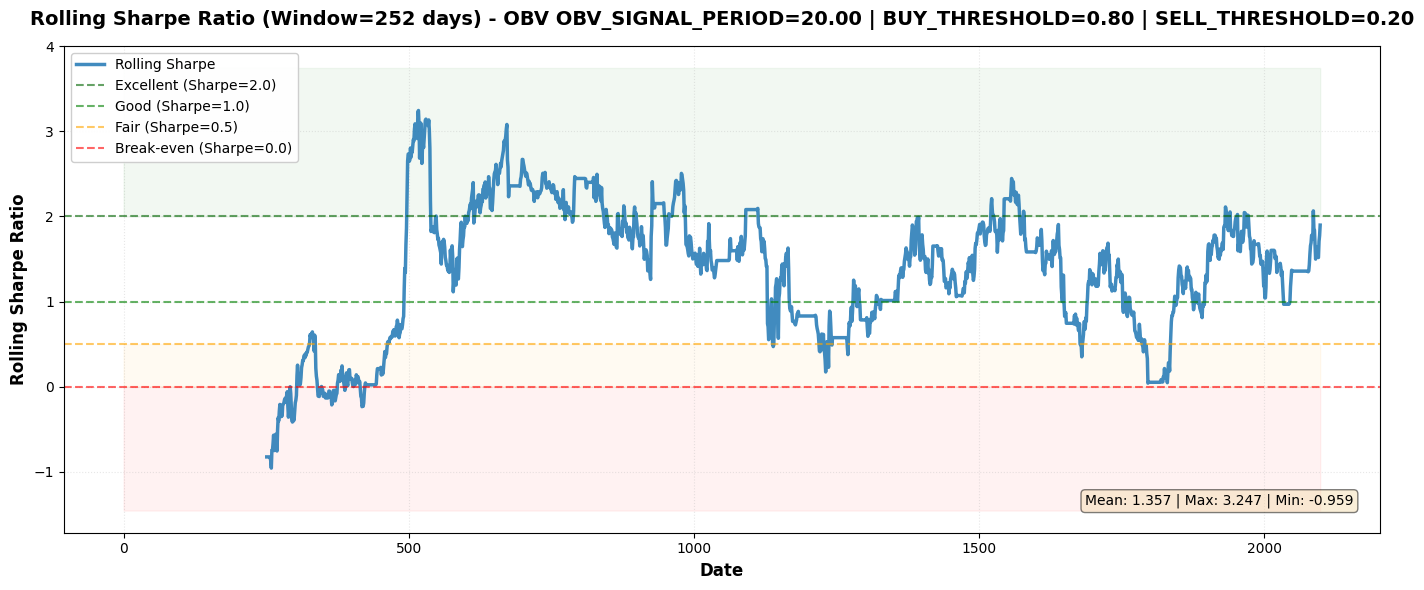

✓ Rolling Sharpe Ratio plot complete
  Window: 252 days
  Mean Sharpe: 1.357
  Max Sharpe: 3.247
  Min Sharpe: -0.959



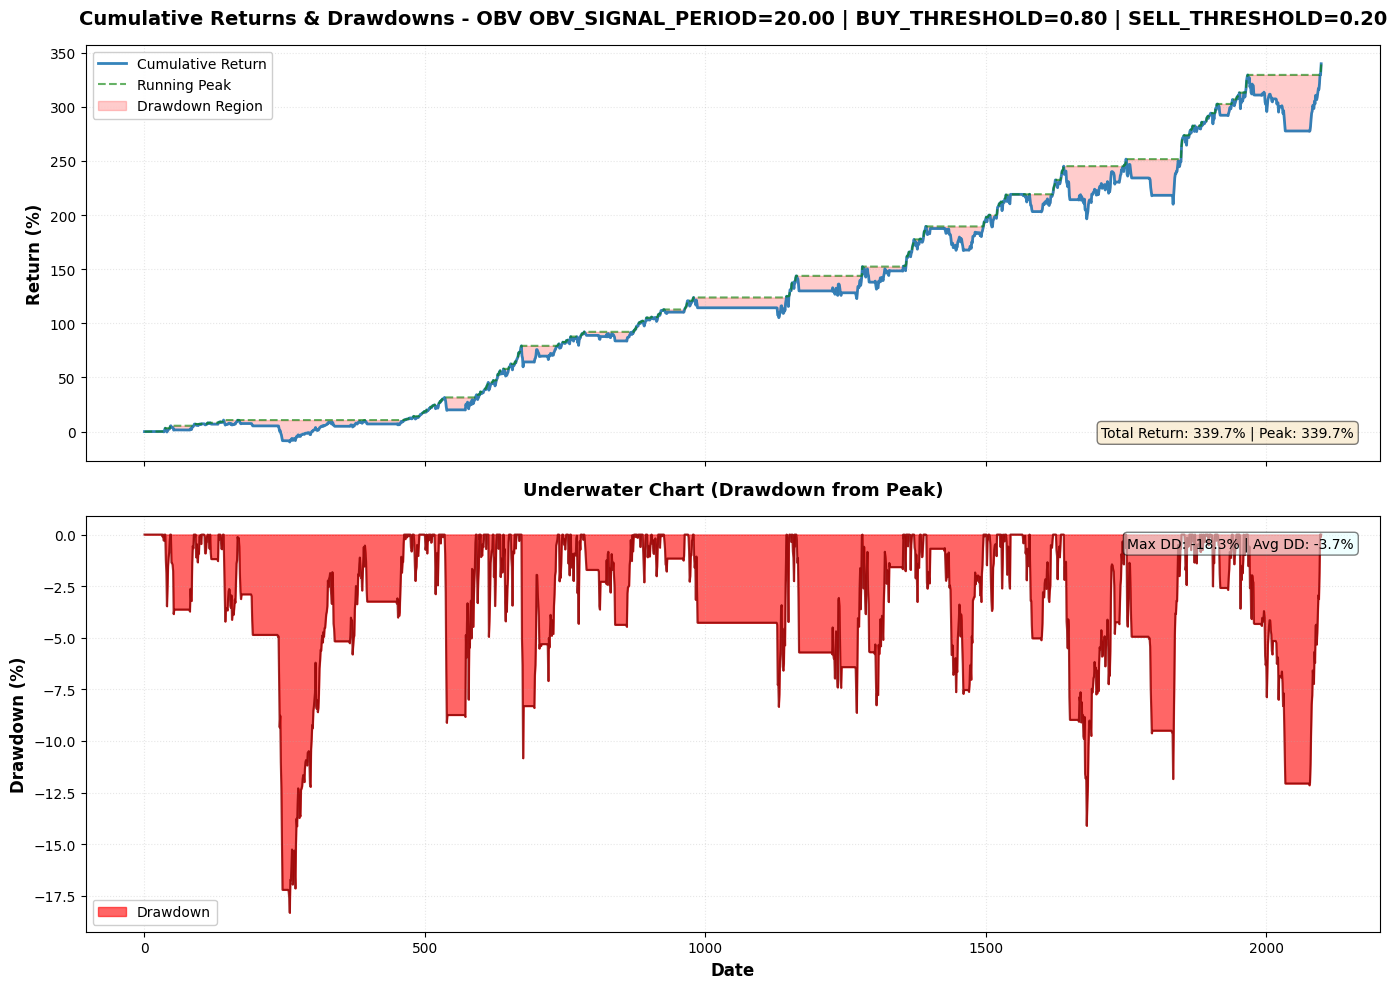

✓ Cumulative returns and drawdown plot complete
  Total Return: 339.67%
  Max Drawdown: -18.33%
  Avg Drawdown: -3.68%


Visualization complete!


In [ ]:
# ROLLING SHARPE & DRAWDOWN ANALYSIS - BEST STRATEGY ON FULL PERIOD

if 'FULL_PERIOD_RETURNS' not in locals():
    print("⚠️ No returns data found. Run cell 13 first.")
else:
    print("=" * 130)
    print("ROLLING SHARPE & DRAWDOWN ANALYSIS")
    print("=" * 130)
    
    print(f"\nStrategy: {INDICATOR.name}")
    print(f"Parameters: {BEST_PARAMS_STR}")
    print(f"Period: {full_close.index[0].date()} to {full_close.index[-1].date()}")
    print(f"Bars: {len(full_close)}\n")
    
    print("Generating visualizations...\n")
    
    try:
        returns_vis = FULL_PERIOD_RETURNS
        
        # ====================================================================
        # SECTION 1: ROLLING SHARPE RATIO VISUALIZATION
        # ====================================================================
        
        # Calculate rolling Sharpe with dynamic window
        rolling_window = max(20, min(TRADING_DAYS_PER_YEAR, max(1, len(returns_vis) // 4)))
        
        if len(returns_vis) > rolling_window:
            
            # Calculate rolling Sharpe
            rolling_sharpe = returns_vis.rolling(window=rolling_window).apply(
                lambda x: (x.mean() * TRADING_DAYS_PER_YEAR) / (x.std() * np.sqrt(TRADING_DAYS_PER_YEAR)) 
                if x.std() and x.std() != 0 else np.nan,
                raw=False
            )
            
            # Plot rolling Sharpe
            fig1 = plt.figure(figsize=(14, 6))
            ax1 = fig1.add_subplot(111)
            
            ax1.plot(rolling_sharpe.index, rolling_sharpe.values, 
                    linewidth=2.5, color='#1f77b4', alpha=0.85, label='Rolling Sharpe')
            
            # Threshold lines
            ax1.axhline(y=2.0, color='darkgreen', linestyle='--', linewidth=1.5, alpha=0.6, label='Excellent (Sharpe=2.0)')
            ax1.axhline(y=1.0, color='green', linestyle='--', linewidth=1.5, alpha=0.6, label='Good (Sharpe=1.0)')
            ax1.axhline(y=0.5, color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Fair (Sharpe=0.5)')
            ax1.axhline(y=0.0, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Break-even (Sharpe=0.0)')
            
            # Shading regions
            ax1.fill_between(rolling_sharpe.index, 2.0, rolling_sharpe.max() + 0.5, 
                            color='green', alpha=0.05)
            ax1.fill_between(rolling_sharpe.index, 0.0, 0.5, 
                            color='orange', alpha=0.05)
            ax1.fill_between(rolling_sharpe.index, rolling_sharpe.min() - 0.5, 0.0, 
                            color='red', alpha=0.05)
            
            ax1.set_title(
                f'Rolling Sharpe Ratio (Window={rolling_window} days) - {INDICATOR.name} {BEST_PARAMS_STR}',
                fontsize=14, fontweight='bold', pad=15
            )
            ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
            ax1.set_ylabel('Rolling Sharpe Ratio', fontsize=12, fontweight='bold')
            ax1.grid(True, alpha=0.3, linestyle=':')
            ax1.legend(loc='upper left', fontsize=10, framealpha=0.95)
            
            # Statistics on plot
            mean_sharpe = rolling_sharpe.mean()
            max_sharpe = rolling_sharpe.max()
            min_sharpe = rolling_sharpe.min()
            
            stats_text = f"Mean: {mean_sharpe:.3f} | Max: {max_sharpe:.3f} | Min: {min_sharpe:.3f}"
            ax1.text(0.98, 0.05, stats_text, 
                    transform=ax1.transAxes, fontsize=10,
                    verticalalignment='bottom', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            plt.tight_layout()
            plt.show()
            
            print(f"✓ Rolling Sharpe Ratio plot complete")
            print(f"  Window: {rolling_window} days")
            print(f"  Mean Sharpe: {mean_sharpe:.3f}")
            print(f"  Max Sharpe: {max_sharpe:.3f}")
            print(f"  Min Sharpe: {min_sharpe:.3f}\n")
        
        else:
            print("⚠️ Not enough data for rolling Sharpe calculation.")
        
        # ====================================================================
        # SECTION 2: CUMULATIVE RETURNS & DRAWDOWNS VISUALIZATION
        # ====================================================================
        
        # Calculate equity curve and drawdowns
        equity_curve = (1 + returns_vis).cumprod()
        peak_curve = equity_curve.cummax()
        drawdown_curve = (equity_curve - peak_curve) / peak_curve
        
        # Create subplot figure
        fig2, (ax_equity, ax_drawdown) = plt.subplots(
            2, 1, figsize=(14, 10), sharex=True
        )
        
        # Upper panel: Equity and Peak
        ax_equity.plot(equity_curve.index, (equity_curve - 1) * 100, 
                      color='#1f77b4', linewidth=2, label='Cumulative Return', alpha=0.9)
        ax_equity.plot(peak_curve.index, (peak_curve - 1) * 100, 
                      color='green', linewidth=1.5, alpha=0.6, label='Running Peak', linestyle='--')
        
        # Fill drawdown area
        ax_equity.fill_between(equity_curve.index, (equity_curve - 1) * 100, (peak_curve - 1) * 100, 
                              color='red', alpha=0.2, label='Drawdown Region')
        
        ax_equity.set_title(
            f'Cumulative Returns & Drawdowns - {INDICATOR.name} {BEST_PARAMS_STR}',
            fontsize=14, fontweight='bold', pad=15
        )
        ax_equity.set_ylabel('Return (%)', fontsize=12, fontweight='bold')
        ax_equity.grid(True, alpha=0.3, linestyle=':')
        ax_equity.legend(loc='upper left', fontsize=10, framealpha=0.95)
        
        # Statistics on upper panel
        total_return_pct = (equity_curve.iloc[-1] - 1) * 100
        max_equity = equity_curve.max()
        equity_stats = f"Total Return: {total_return_pct:.1f}% | Peak: {(max_equity - 1) * 100:.1f}%"
        ax_equity.text(0.98, 0.05, equity_stats, 
                      transform=ax_equity.transAxes, fontsize=10,
                      verticalalignment='bottom', horizontalalignment='right',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # Lower panel: Underwater chart
        ax_drawdown.fill_between(drawdown_curve.index, drawdown_curve * 100, 0, 
                                color='red', alpha=0.6, label='Drawdown')
        ax_drawdown.plot(drawdown_curve.index, drawdown_curve * 100, 
                        color='darkred', linewidth=1.5, alpha=0.8)
        
        ax_drawdown.set_title(
            'Underwater Chart (Drawdown from Peak)',
            fontsize=13, fontweight='bold', pad=15
        )
        ax_drawdown.set_xlabel('Date', fontsize=12, fontweight='bold')
        ax_drawdown.set_ylabel('Drawdown (%)', fontsize=12, fontweight='bold')
        ax_drawdown.grid(True, alpha=0.3, linestyle=':')
        ax_drawdown.legend(loc='lower left', fontsize=10, framealpha=0.95)
        
        # Statistics on lower panel
        max_drawdown_pct = drawdown_curve.min() * 100
        avg_drawdown_pct = drawdown_curve.mean() * 100
        dd_stats = f"Max DD: {max_drawdown_pct:.1f}% | Avg DD: {avg_drawdown_pct:.1f}%"
        ax_drawdown.text(0.98, 0.95, dd_stats, 
                        transform=ax_drawdown.transAxes, fontsize=10,
                        verticalalignment='top', horizontalalignment='right',
                        bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
        
        print(f"✓ Cumulative returns and drawdown plot complete")
        print(f"  Total Return: {total_return_pct:.2f}%")
        print(f"  Max Drawdown: {max_drawdown_pct:.2f}%")
        print(f"  Avg Drawdown: {avg_drawdown_pct:.2f}%\n")
        
    except Exception as e:
        print(f"⚠️ Error during visualization: {str(e)[:150]}")
        import traceback
        traceback.print_exc()

print("\nVisualization complete!")

SIGNAL & EQUITY CURVE VISUALIZATIONS

Strategy: OBV
Parameters: OBV_SIGNAL_PERIOD=20.00 | BUY_THRESHOLD=0.80 | SELL_THRESHOLD=0.20
Full Period: 2018-01-02 to 2026-05-08

Computing indicators and signals for visualization...
✓ Complete

Creating signal visualization...


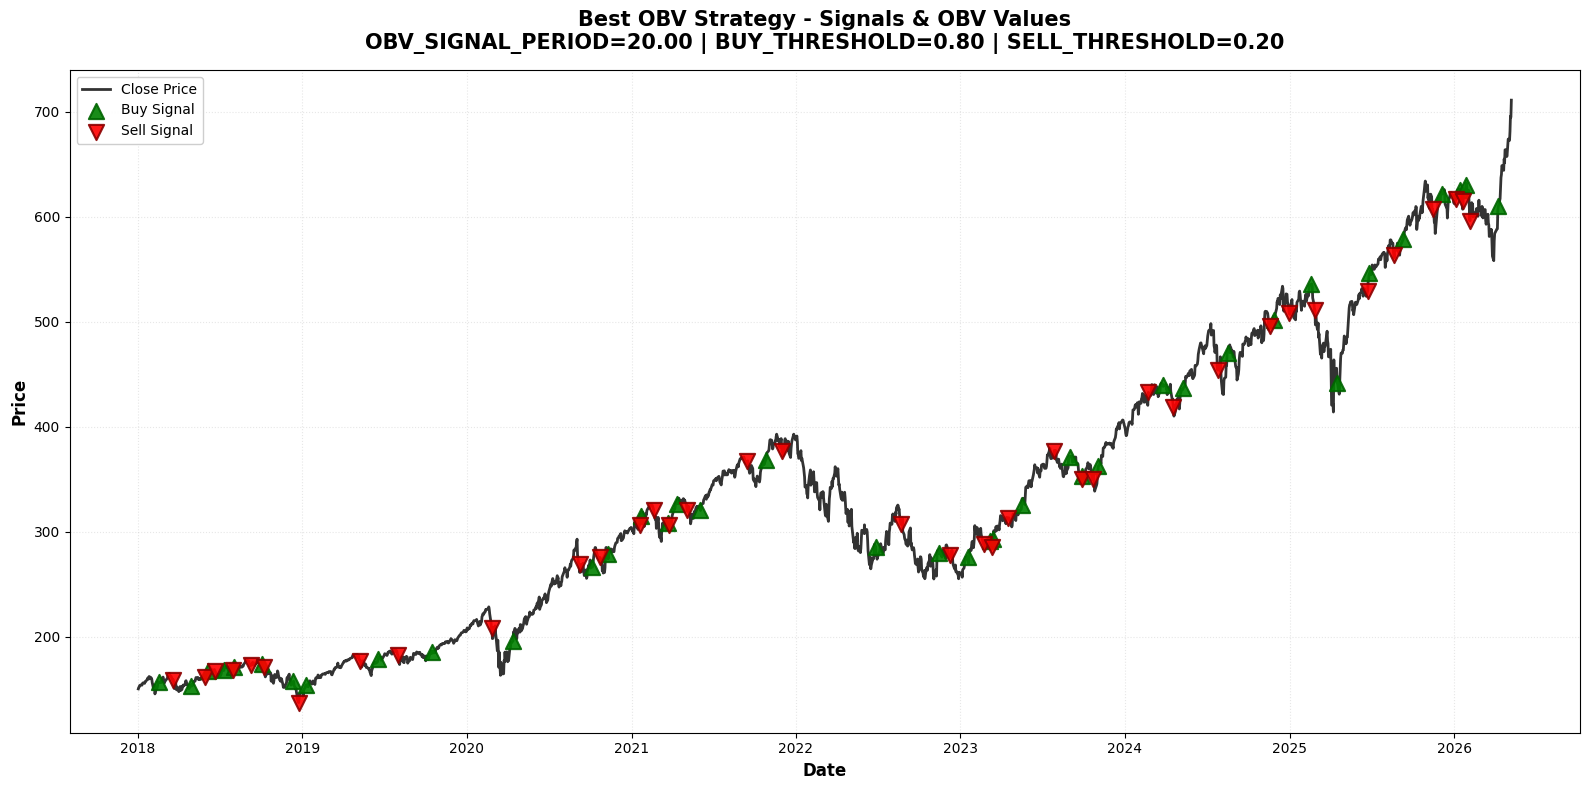

✓ Signal visualization complete

Computing equity curves from stored returns...
✓ Complete



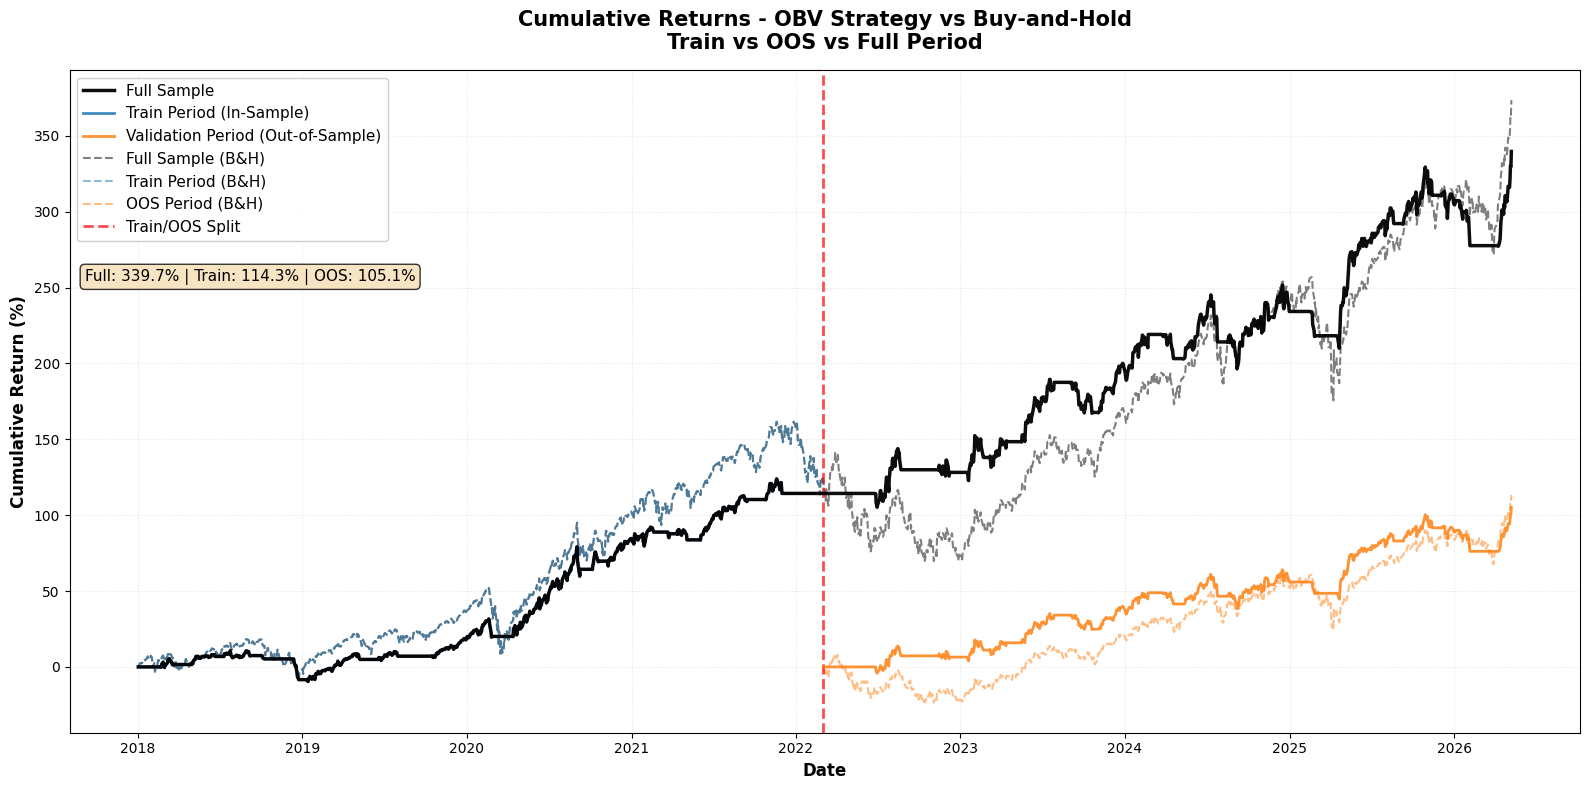

📈 EQUITY CURVE COMPARISON STATISTICS

Cumulative Returns:
  Full Sample:            339.67%
  Train Period:           114.32%
  OOS Period:             105.15%
  OOS/Train Ratio:          0.92x

Max Drawdown Duration (days):
  Full Sample:               321
  Train Period:              321
  OOS Period:                128

Annualized Volatility:
  Full Sample:            13.45%
  Train Period:           13.00%
  OOS Period:             13.88%

✅ Signal and equity curve analysis complete!

Visualization complete!


In [ ]:
# SIGNAL & EQUITY CURVE VISUALIZATIONS - BEST STRATEGY

if 'BEST_PARAMS' not in locals() or 'IS_RETURNS' not in locals() or 'OOS_RETURNS' not in locals() or 'FULL_PERIOD_RETURNS' not in locals():
    print("⚠️ Missing required data. Run cells 13-15 first.")
else:
    print("=" * 130)
    print("SIGNAL & EQUITY CURVE VISUALIZATIONS")
    print("=" * 130)
    
    print(f"\nStrategy: {INDICATOR.name}")
    print(f"Parameters: {BEST_PARAMS_STR}")
    print(f"Full Period: {full_close.index[0].date()} to {full_close.index[-1].date()}\n")
    
    try:
        # ====================================================================
        # STEP 1: CALCULATE INDICATORS & SIGNALS ON FULL PERIOD (for visualization only)
        # ====================================================================
        
        print("Computing indicators and signals for visualization...")
        
        indicators_plot = INDICATOR.calc_func(full_close, **kwargs_full, **BEST_PARAMS)
        entries_plot, exits_plot = INDICATOR.signal_func(indicators_plot, **BEST_PARAMS)
        
        # Convert to boolean arrays
        entries_plot_arr = entries_plot.values if isinstance(entries_plot, pd.Series) else entries_plot
        exits_plot_arr = exits_plot.values if isinstance(exits_plot, pd.Series) else exits_plot
        
        print("✓ Complete\n")
        
        # ====================================================================
        # SECTION 1: PRICE + INDICATOR VALUES + SIGNALS VISUALIZATION
        # ====================================================================
        
        print("Creating signal visualization...")
        
        fig_signals = plt.figure(figsize=(16, 8))
        ax_signals = fig_signals.add_subplot(111)
        
        # Plot price
        ax_signals.plot(full_close.index, full_close.values, 
                       label='Close Price', color='black', linewidth=2, alpha=0.8, zorder=3)
        
        # Plot indicator-specific visualizations
        if INDICATOR.name == 'TEMA':
            # Plot the three EMAs
            ax_signals.plot(full_close.index, indicators_plot['ema1'].values, 
                           label=f"Fast EMA ({BEST_PARAMS['ema1_period']})", 
                           color='blue', alpha=0.75, linewidth=1.5)
            ax_signals.plot(full_close.index, indicators_plot['ema2'].values, 
                           label=f"Medium EMA ({BEST_PARAMS['ema2_period']})", 
                           color='orange', alpha=0.75, linewidth=1.5)
            ax_signals.plot(full_close.index, indicators_plot['ema3'].values, 
                           label=f"Slow EMA ({BEST_PARAMS['ema3_period']})", 
                           color='purple', alpha=0.75, linewidth=1.5)
        
        elif INDICATOR.name == 'MACD':
            # Create secondary y-axis for MACD
            ax_macd = ax_signals.twinx()
            ax_macd.plot(full_close.index, indicators_plot['macd'].values, 
                        label=f"MACD ({BEST_PARAMS['fast_period']},{BEST_PARAMS['slow_period']})", 
                        color='blue', alpha=0.75, linewidth=1.5)
            ax_macd.plot(full_close.index, indicators_plot['signal'].values, 
                        label=f"Signal ({BEST_PARAMS['signal_period']})", 
                        color='red', alpha=0.75, linewidth=1.5)
            ax_macd.fill_between(full_close.index, 0, indicators_plot['histogram'].values, 
                                alpha=0.2, color='gray')
            ax_macd.set_ylabel('MACD Value', fontsize=11, fontweight='bold')
            ax_macd.legend(loc='upper left', fontsize=9)
        
        elif INDICATOR.name == 'STC':
            # Create secondary y-axis for STC
            ax_stc = ax_signals.twinx()
            ax_stc.plot(full_close.index, indicators_plot['stc_k'].values, 
                       label=f"STC K ({BEST_PARAMS['macd_fast']},{BEST_PARAMS['macd_slow']})", 
                       color='blue', alpha=0.75, linewidth=1.5)
            ax_stc.plot(full_close.index, indicators_plot['stc_d'].values, 
                       label=f"STC D ({BEST_PARAMS['stc_signal']})", 
                       color='red', alpha=0.75, linewidth=1.5)
            ax_stc.fill_between(full_close.index, 20, 80, alpha=0.1, color='gray')
            ax_stc.axhline(y=50, color='gray', linestyle='--', alpha=0.3)
            ax_stc.set_ylabel('STC (0-100)', fontsize=11, fontweight='bold')
            ax_stc.set_ylim([0, 100])
            ax_stc.legend(loc='upper left', fontsize=9)
        
        elif INDICATOR.name == 'RSI':
            # Create secondary y-axis for RSI
            ax_rsi = ax_signals.twinx()
            ax_rsi.plot(full_close.index, indicators_plot['rsi'].values, 
                       label=f"RSI ({BEST_PARAMS['period']})", 
                       color='blue', alpha=0.75, linewidth=1.5)
            ax_rsi.axhline(y=70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
            ax_rsi.axhline(y=30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
            ax_rsi.fill_between(full_close.index, 30, 70, alpha=0.1, color='gray')
            ax_rsi.set_ylabel('RSI (0-100)', fontsize=11, fontweight='bold')
            ax_rsi.set_ylim([0, 100])
            ax_rsi.legend(loc='upper left', fontsize=9)
        
        # Filter signals to only show position transitions
        position_state = np.zeros(len(full_close), dtype=int)  # 0 = no position, 1 = in position

        for i in range(len(full_close)):
            if i == 0:
                position_state[i] = 1 if entries_plot_arr[i] else 0
            else:
                position_state[i] = position_state[i-1]
                if entries_plot_arr[i] and position_state[i-1] == 0:
                    position_state[i] = 1
                elif exits_plot_arr[i] and position_state[i-1] == 1:
                    position_state[i] = 0

        entries_plot_filtered = np.zeros_like(entries_plot_arr)
        exits_plot_filtered = np.zeros_like(exits_plot_arr)

        for i in range(1, len(full_close)):
            if position_state[i] == 1 and position_state[i-1] == 0:
                entries_plot_filtered[i] = True
            elif position_state[i] == 0 and position_state[i-1] == 1:
                exits_plot_filtered[i] = True

        buy_indices = full_close.index[entries_plot_filtered.astype(bool)]
        sell_indices = full_close.index[exits_plot_filtered.astype(bool)]
        
        buy_prices = full_close.loc[buy_indices]
        sell_prices = full_close.loc[sell_indices]
        
        ax_signals.scatter(buy_indices, buy_prices.values, 
                          marker='^', color='green', s=120, label='Buy Signal', 
                          edgecolors='darkgreen', linewidth=1.5, zorder=5, alpha=0.9)
        ax_signals.scatter(sell_indices, sell_prices.values, 
                          marker='v', color='red', s=120, label='Sell Signal', 
                          edgecolors='darkred', linewidth=1.5, zorder=5, alpha=0.9)
        
        # Formatting
        ax_signals.set_title(
            f'Best {INDICATOR.name} Strategy - Signals & {INDICATOR.name} Values\n{BEST_PARAMS_STR}',
            fontsize=15, fontweight='bold', pad=15
        )
        ax_signals.set_xlabel('Date', fontsize=12, fontweight='bold')
        ax_signals.set_ylabel('Price', fontsize=12, fontweight='bold')
        ax_signals.grid(True, alpha=0.3, linestyle=':')
        
        handles_main, labels_main = ax_signals.get_legend_handles_labels()
        ax_signals.legend(handles_main, labels_main, loc='best', fontsize=10, framealpha=0.95)
        
        plt.tight_layout()
        plt.show()
        
        print("✓ Signal visualization complete\n")
        
        # ====================================================================
        # SECTION 2: EQUITY CURVES - TRAIN / OOS / FULL PERIOD (using stored returns)
        # ====================================================================
        
        print("Computing equity curves from stored returns...")
        
        # Calculate cumulative equity from stored returns
        eq_full_viz = (1 + FULL_PERIOD_RETURNS).cumprod()
        eq_train_viz = (1 + IS_RETURNS).cumprod()
        eq_oos_viz = (1 + OOS_RETURNS).cumprod()

        # Calculate buy-and-hold benchmark returns for each period
        bh_full = (full_close.values / full_close.iloc[0] - 1) * 100
        bh_train = (train_close.values / train_close.iloc[0] - 1) * 100
        bh_oos = (val_close.values / val_close.iloc[0] - 1) * 100
        
        print("✓ Complete\n")
        
        # ====================================================================
        # PLOT EQUITY CURVES
        # ====================================================================
        
        fig_equity = plt.figure(figsize=(16, 8))
        ax_equity = fig_equity.add_subplot(111)
        
        # Plot equity curves
        ax_equity.plot(full_close.index, (eq_full_viz.values - 1) * 100, 
                      label='Full Sample', color='black', linewidth=2.5, alpha=0.95, zorder=5)
        ax_equity.plot(train_close.index, (eq_train_viz.values - 1) * 100, 
                      label='Train Period (In-Sample)', color='#1f77b4', 
                      linewidth=2, alpha=0.85, zorder=4)
        ax_equity.plot(val_close.index, (eq_oos_viz.values - 1) * 100, 
                      label='Validation Period (Out-of-Sample)', color='#ff7f0e', 
                      linewidth=2, alpha=0.85, zorder=4)
        
        # Plot buy-and-hold benchmarks
        ax_equity.plot(full_close.index, bh_full, 
                    label='Full Sample (B&H)', color='black', linewidth=1.5, alpha=0.5, 
                    linestyle='--', zorder=3)
        ax_equity.plot(train_close.index, bh_train, 
                    label='Train Period (B&H)', color='#1f77b4', linewidth=1.5, alpha=0.5, 
                    linestyle='--', zorder=3)
        ax_equity.plot(val_close.index, bh_oos, 
                    label='OOS Period (B&H)', color='#ff7f0e', linewidth=1.5, alpha=0.5, 
                    linestyle='--', zorder=3)
        
        # Add vertical line at train/validation split
        split_date = train_close.index[-1]
        ax_equity.axvline(x=split_date, color='red', linestyle='--', 
                         linewidth=2, alpha=0.7, label='Train/OOS Split', zorder=3)
        
        # Formatting
        ax_equity.set_title(
            f'Cumulative Returns - {INDICATOR.name} Strategy vs Buy-and-Hold\nTrain vs OOS vs Full Period',
            fontsize=15, fontweight='bold', pad=15
        )
        ax_equity.set_xlabel('Date', fontsize=12, fontweight='bold')
        ax_equity.set_ylabel('Cumulative Return (%)', fontsize=12, fontweight='bold')
        ax_equity.grid(True, alpha=0.3, linestyle=':')
        ax_equity.legend(loc='upper left', fontsize=11, framealpha=0.95)
        
        # Add return statistics on plot
        final_return_full = (eq_full_viz.iloc[-1] - 1) * 100
        final_return_train = (eq_train_viz.iloc[-1] - 1) * 100
        final_return_oos = (eq_oos_viz.iloc[-1] - 1) * 100
        
        stats_text = (
            f"Full: {final_return_full:.1f}% | "
            f"Train: {final_return_train:.1f}% | "
            f"OOS: {final_return_oos:.1f}%"
        )
        ax_equity.text(0.01, 0.70, stats_text, transform=ax_equity.transAxes, 
                      fontsize=11, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
        # ====================================================================
        # SECTION 3: EQUITY CURVE COMPARISON STATISTICS
        # ====================================================================
        
        print("=" * 130)
        print("📈 EQUITY CURVE COMPARISON STATISTICS")
        print("=" * 130)
        
        print(f"\nCumulative Returns:")
        print(f"  Full Sample:        {final_return_full:>10.2f}%")
        print(f"  Train Period:       {final_return_train:>10.2f}%")
        print(f"  OOS Period:         {final_return_oos:>10.2f}%")
        print(f"  OOS/Train Ratio:    {final_return_oos/final_return_train if final_return_train != 0 else 0:>10.2f}x")
        
        # Calculate underwater period durations
        def get_max_drawdown_duration(eq_curve):
            peak = eq_curve.cummax()
            drawdown_days = (eq_curve < peak).astype(int)
            underwater_periods = []
            current_period = 0
            
            for i in range(len(drawdown_days)):
                if drawdown_days.iloc[i] == 1:
                    current_period += 1
                else:
                    if current_period > 0:
                        underwater_periods.append(current_period)
                    current_period = 0
            
            if current_period > 0:
                underwater_periods.append(current_period)
            
            return max(underwater_periods) if underwater_periods else 0
        
        dd_duration_full = get_max_drawdown_duration(eq_full_viz)
        dd_duration_train = get_max_drawdown_duration(eq_train_viz)
        dd_duration_oos = get_max_drawdown_duration(eq_oos_viz)
        
        print(f"\nMax Drawdown Duration (days):")
        print(f"  Full Sample:        {dd_duration_full:>10.0f}")
        print(f"  Train Period:       {dd_duration_train:>10.0f}")
        print(f"  OOS Period:         {dd_duration_oos:>10.0f}")
        
        # Calculate volatility from stored returns
        vol_full = FULL_PERIOD_RETURNS.std() * np.sqrt(TRADING_DAYS_PER_YEAR)
        vol_train = IS_RETURNS.std() * np.sqrt(TRADING_DAYS_PER_YEAR)
        vol_oos = OOS_RETURNS.std() * np.sqrt(TRADING_DAYS_PER_YEAR)
        
        print(f"\nAnnualized Volatility:")
        print(f"  Full Sample:        {vol_full:>10.2%}")
        print(f"  Train Period:       {vol_train:>10.2%}")
        print(f"  OOS Period:         {vol_oos:>10.2%}")
        
        print("\n" + "=" * 130)
        print("✅ Signal and equity curve analysis complete!")
        print("=" * 130)
        
    except Exception as e:
        print(f"⚠️ Error during visualization: {str(e)[:150]}")
        import traceback
        traceback.print_exc()

print("\nVisualization complete!")

TRADE-BY-TRADE ANALYSIS - FULL PERIOD

Strategy: OBV
Parameters: OBV_SIGNAL_PERIOD=20.00 | BUY_THRESHOLD=0.80 | SELL_THRESHOLD=0.20
Period: Full Sample (2018-01-02 to 2026-05-08)
Total Bars: 2099

📊 TRADE STATISTICS

Trade Counts:
  Total Trades:                 39
  Winning Trades:               24  ( 61.5%)
  Losing Trades:                15  ( 38.5%)
  Breakeven Trades:              0

Per-Trade Returns:
  Average Win:              0.0880  (  8.80%)
  Average Loss:            -0.0307  ( -3.07%)
  Max Win:                  0.3685  ( 36.85%)
  Max Loss:                -0.1299  (-12.99%)

Aggregate Returns:
  Total Gains:              2.1120
  Total Losses:            -0.4605
  Profit Factor:              4.59  (Gains/Losses ratio)
  Average Return/Trade:     0.0423  (  4.23%)

Risk Metrics:
  Trade Return Std Dev:     0.0897
  Best Trade:               0.3685  ( 36.85%)
  Worst Trade:             -0.1299  (-12.99%)
  Trade Return Range:       0.4984

Creating trade visualization...


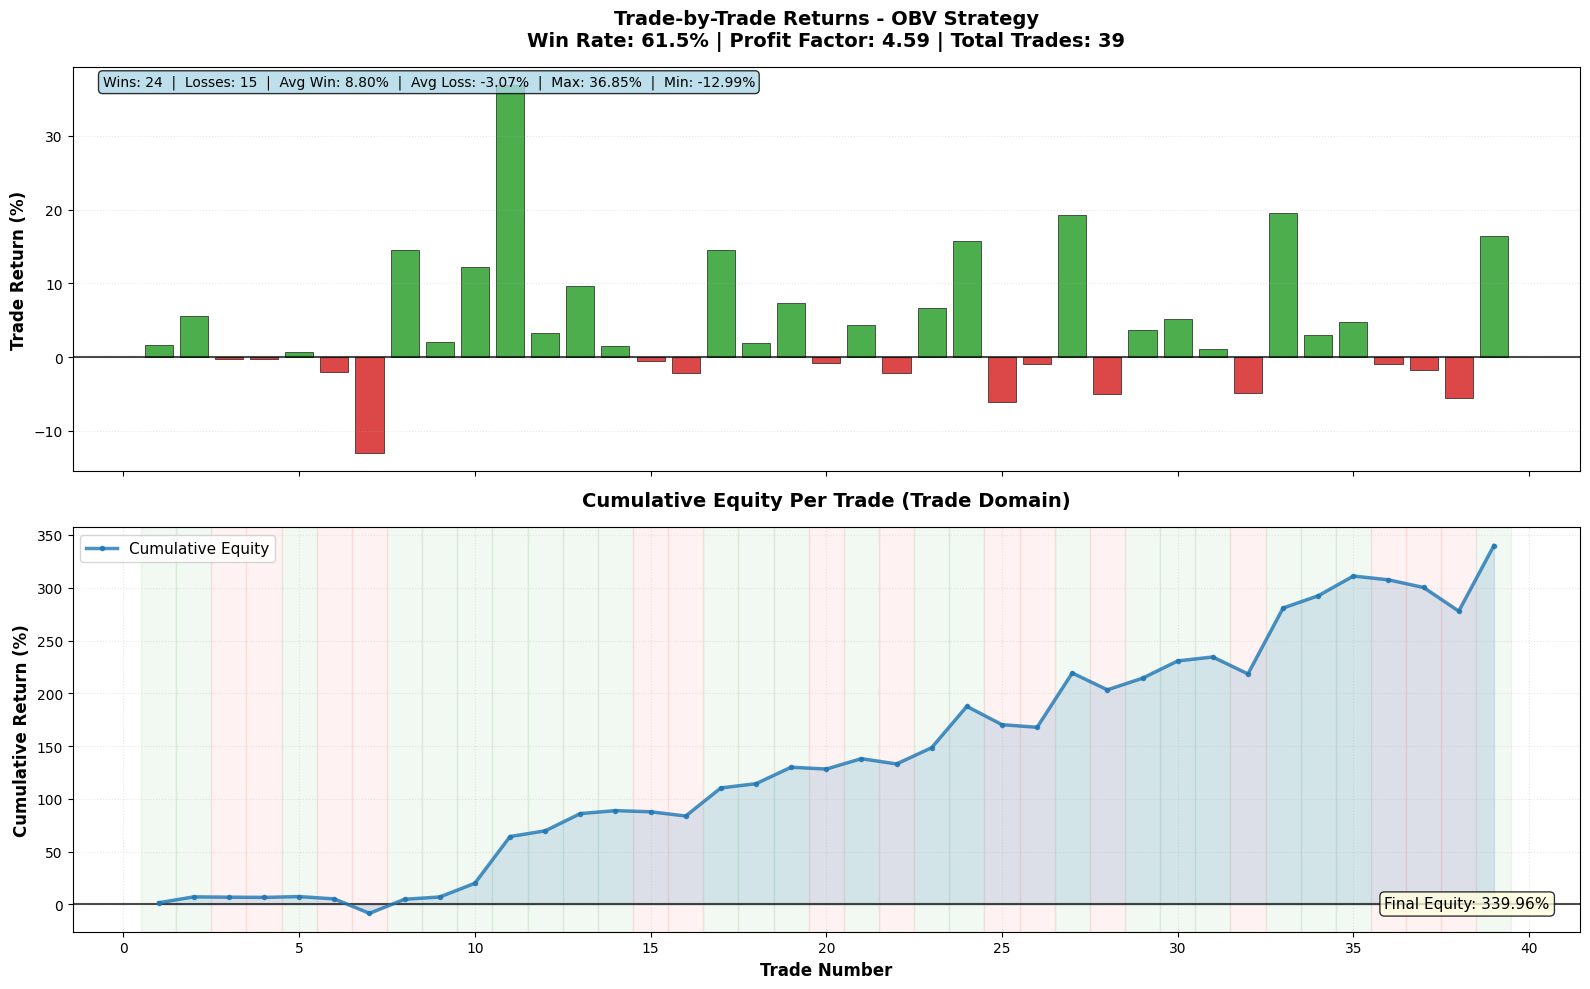

✓ Trade visualization complete

📈 TRADE DISTRIBUTION ANALYSIS

Return Quartiles:
  25th Percentile (Q1):     -0.0090  (  -0.90%)
  50th Percentile (Q2):      0.0191  (   1.91%)  ← Median
  75th Percentile (Q3):      0.0695  (   6.95%)
  IQR (Q3-Q1):               0.0784  (   7.84%)

Return Distribution:
  Exceptional Win (>10%)                 8 trades  ( 20.5%)
  Large Win (5%-10%)                     5 trades  ( 12.8%)
  Medium Win (1%-5%)                    10 trades  ( 25.6%)
  Small Win (0%-1%)                      1 trades  (  2.6%)
  Breakeven                              0 trades  (  0.0%)
  Small Loss (0% to -1%)                 6 trades  ( 15.4%)
  Medium Loss (-1% to -5%)               6 trades  ( 15.4%)
  Large Loss (-5% to -10%)               2 trades  (  5.1%)
  Exceptional Loss (<-10%)               1 trades  (  2.6%)

Consecutive Trade Patterns:
  Max Consecutive Wins:            7
  Max Consecutive Losses:          3

Expectancy Analysis:
  Payoff Ratio (Avg Win / Avg 

In [ ]:
# TRADE-BY-TRADE RETURNS (BAR) + CUMULATIVE PER-TRADE EQUITY — ALL TRADES

if 'FULL_PERIOD_RETURNS' not in locals() or 'BEST_PARAMS' not in locals():
    print("⚠️ Missing required data. Run cell 13 first.")
else:
    print("=" * 130)
    print("TRADE-BY-TRADE ANALYSIS - FULL PERIOD")
    print("=" * 130)
    
    # ========================================================================
    # STEP 1: RECALCULATE BACKTEST TO EXTRACT TRADES (for trade analysis only)
    # ========================================================================
    
    try:
        # Calculate indicator and signals
        indicators_trades = INDICATOR.calc_func(full_close, **kwargs_full, **BEST_PARAMS)
        entries_trades, exits_trades = INDICATOR.signal_func(indicators_trades, **BEST_PARAMS)
        
        entries_arr = entries_trades.values.astype(bool) if isinstance(entries_trades, pd.Series) else entries_trades.astype(bool)
        exits_arr = exits_trades.values.astype(bool) if isinstance(exits_trades, pd.Series) else exits_trades.astype(bool)
        
        # Run backtest
        pf_trades = vbt.Portfolio.from_signals(
            close=full_close.values.astype(float),
            entries=entries_arr,
            exits=exits_arr,
            init_cash=100_000,
            fees=0.0005,
            slippage=0.0005,
            freq=FREQ
        )
        
        trades_full_analysis = pf_trades.trades
        
        # Extract trade returns as 1D array
        trade_returns = (
            trades_full_analysis.returns.values 
            if hasattr(trades_full_analysis.returns, 'values') 
            else np.asarray(trades_full_analysis.returns)
        )
        trade_returns = np.asarray(trade_returns).ravel()
        
        print(f"\nStrategy: {INDICATOR.name}")
        print(f"Parameters: {BEST_PARAMS_STR}")
        print(f"Period: Full Sample ({full_close.index[0].date()} to {full_close.index[-1].date()})")
        print(f"Total Bars: {len(full_close)}\n")
        
        if trade_returns.size == 0:
            print("⚠️ No trades executed in full period.")
        else:
            # ====================================================================
            # SECTION 1: TRADE STATISTICS
            # ====================================================================
            
            winning_trades = trade_returns[trade_returns > 0]
            losing_trades = trade_returns[trade_returns < 0]
            breakeven_trades = trade_returns[trade_returns == 0]
            
            total_trades = len(trade_returns)
            num_wins = len(winning_trades)
            num_losses = len(losing_trades)
            num_breakeven = len(breakeven_trades)
            
            win_rate_pct = (num_wins / total_trades * 100) if total_trades > 0 else 0
            loss_rate_pct = (num_losses / total_trades * 100) if total_trades > 0 else 0
            
            avg_win = winning_trades.mean() if len(winning_trades) > 0 else 0
            avg_loss = losing_trades.mean() if len(losing_trades) > 0 else 0
            
            total_gains = winning_trades.sum() if len(winning_trades) > 0 else 0
            total_losses = losing_trades.sum() if len(losing_trades) > 0 else 0
            
            profit_factor = abs(total_gains / total_losses) if total_losses != 0 else np.inf
            
            print("=" * 130)
            print("📊 TRADE STATISTICS")
            print("=" * 130)
            
            print(f"\nTrade Counts:")
            print(f"  Total Trades:         {total_trades:>10.0f}")
            print(f"  Winning Trades:       {num_wins:>10.0f}  ({win_rate_pct:>5.1f}%)")
            print(f"  Losing Trades:        {num_losses:>10.0f}  ({loss_rate_pct:>5.1f}%)")
            print(f"  Breakeven Trades:     {num_breakeven:>10.0f}")
            
            print(f"\nPer-Trade Returns:")
            print(f"  Average Win:          {avg_win:>10.4f}  ({avg_win*100:>6.2f}%)")
            print(f"  Average Loss:         {avg_loss:>10.4f}  ({avg_loss*100:>6.2f}%)")
            if len(winning_trades) > 0:
                print(f"  Max Win:              {winning_trades.max():>10.4f}  ({winning_trades.max()*100:>6.2f}%)")
            else:
                print(f"  Max Win:                        N/A")
            if len(losing_trades) > 0:
                print(f"  Max Loss:             {losing_trades.min():>10.4f}  ({losing_trades.min()*100:>6.2f}%)")
            else:
                print(f"  Max Loss:                       N/A")
            
            print(f"\nAggregate Returns:")
            print(f"  Total Gains:          {total_gains:>10.4f}")
            print(f"  Total Losses:         {total_losses:>10.4f}")
            print(f"  Profit Factor:        {profit_factor:>10.2f}  (Gains/Losses ratio)")
            print(f"  Average Return/Trade: {trade_returns.mean():>10.4f}  ({trade_returns.mean()*100:>6.2f}%)")
            
            print(f"\nRisk Metrics:")
            print(f"  Trade Return Std Dev: {trade_returns.std():>10.4f}")
            print(f"  Best Trade:           {trade_returns.max():>10.4f}  ({trade_returns.max()*100:>6.2f}%)")
            print(f"  Worst Trade:          {trade_returns.min():>10.4f}  ({trade_returns.min()*100:>6.2f}%)")
            print(f"  Trade Return Range:   {trade_returns.max() - trade_returns.min():>10.4f}")
            
            # ====================================================================
            # SECTION 2: TRADE-BY-TRADE BAR CHART + CUMULATIVE EQUITY
            # ====================================================================
            
            print("\n" + "=" * 130)
            print("Creating trade visualization...")
            
            # Calculate cumulative equity per trade
            equity_per_trade = np.cumprod(1.0 + trade_returns)
            
            # Create figure with 2 subplots
            fig_trades, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
            
            # Trade index
            trade_idx = np.arange(1, trade_returns.size + 1)
            
            # Color bars: green for wins, red for losses
            colors = np.where(trade_returns >= 0, '#2ca02c', '#d62728')
            
            # ====================================================================
            # UPPER PANEL: TRADE-BY-TRADE RETURNS (BAR CHART)
            # ====================================================================
            
            bars = axes[0].bar(trade_idx, trade_returns * 100.0, color=colors, 
                              alpha=0.85, width=0.8, edgecolor='black', linewidth=0.5)
            
            axes[0].axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
            axes[0].set_title(
                f'Trade-by-Trade Returns - {INDICATOR.name} Strategy\n'
                f'Win Rate: {win_rate_pct:.1f}% | Profit Factor: {profit_factor:.2f} | Total Trades: {total_trades}',
                fontsize=14, fontweight='bold', pad=15
            )
            axes[0].set_ylabel('Trade Return (%)', fontsize=12, fontweight='bold')
            axes[0].grid(True, alpha=0.3, linestyle=':', axis='y')
            
            # Add statistics box on upper panel
            stats_text_upper = (
                f"Wins: {num_wins}  |  Losses: {num_losses}  |  Avg Win: {avg_win*100:.2f}%  |  "
                f"Avg Loss: {avg_loss*100:.2f}%  |  Max: {trade_returns.max()*100:.2f}%  |  "
                f"Min: {trade_returns.min()*100:.2f}%"
            )
            axes[0].text(0.02, 0.98, stats_text_upper, transform=axes[0].transAxes, 
                        fontsize=10, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
            
            # ====================================================================
            # LOWER PANEL: CUMULATIVE EQUITY PER TRADE (LINE CHART)
            # ====================================================================
            
            axes[1].plot(trade_idx, (equity_per_trade - 1) * 100, 
                        color='#1f77b4', linewidth=2.5, marker='o', markersize=3, 
                        alpha=0.8, label='Cumulative Equity', zorder=3)
            
            # Fill area under curve
            axes[1].fill_between(trade_idx, 0, (equity_per_trade - 1) * 100, 
                                alpha=0.15, color='#1f77b4', zorder=1)
            
            # Highlight wins vs losses with background
            for i, ret in enumerate(trade_returns):
                if ret > 0:
                    axes[1].axvspan(trade_idx[i] - 0.5, trade_idx[i] + 0.5, 
                                  alpha=0.05, color='green', zorder=0)
                else:
                    axes[1].axvspan(trade_idx[i] - 0.5, trade_idx[i] + 0.5, 
                                  alpha=0.05, color='red', zorder=0)
            
            axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
            axes[1].set_title(
                'Cumulative Equity Per Trade (Trade Domain)',
                fontsize=14, fontweight='bold', pad=15
            )
            axes[1].set_xlabel('Trade Number', fontsize=12, fontweight='bold')
            axes[1].set_ylabel('Cumulative Return (%)', fontsize=12, fontweight='bold')
            axes[1].grid(True, alpha=0.3, linestyle=':')
            axes[1].legend(loc='upper left', fontsize=11)
            
            # Add final equity annotation on lower panel
            final_equity_pct = (equity_per_trade[-1] - 1) * 100
            axes[1].text(0.98, 0.05, f'Final Equity: {final_equity_pct:.2f}%', 
                        transform=axes[1].transAxes, fontsize=11, 
                        horizontalalignment='right', verticalalignment='bottom',
                        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
            
            plt.tight_layout()
            plt.show()
            
            print("✓ Trade visualization complete\n")
            
            # ====================================================================
            # SECTION 3: TRADE DISTRIBUTION ANALYSIS
            # ====================================================================
            
            print("=" * 130)
            print("📈 TRADE DISTRIBUTION ANALYSIS")
            print("=" * 130)
            
            # Quartile analysis
            print(f"\nReturn Quartiles:")
            q1, q2, q3 = np.percentile(trade_returns, [25, 50, 75])
            print(f"  25th Percentile (Q1):  {q1:>10.4f}  ({q1*100:>7.2f}%)")
            print(f"  50th Percentile (Q2):  {q2:>10.4f}  ({q2*100:>7.2f}%)  ← Median")
            print(f"  75th Percentile (Q3):  {q3:>10.4f}  ({q3*100:>7.2f}%)")
            print(f"  IQR (Q3-Q1):           {q3-q1:>10.4f}  ({(q3-q1)*100:>7.2f}%)")
            
            # Distribution buckets
            print(f"\nReturn Distribution:")
            buckets = {
                'Exceptional Win (>10%)': len(trade_returns[trade_returns > 0.10]),
                'Large Win (5%-10%)': len(trade_returns[(trade_returns > 0.05) & (trade_returns <= 0.10)]),
                'Medium Win (1%-5%)': len(trade_returns[(trade_returns > 0.01) & (trade_returns <= 0.05)]),
                'Small Win (0%-1%)': len(trade_returns[(trade_returns > 0) & (trade_returns <= 0.01)]),
                'Breakeven': len(trade_returns[trade_returns == 0]),
                'Small Loss (0% to -1%)': len(trade_returns[(trade_returns < 0) & (trade_returns >= -0.01)]),
                'Medium Loss (-1% to -5%)': len(trade_returns[(trade_returns < -0.01) & (trade_returns >= -0.05)]),
                'Large Loss (-5% to -10%)': len(trade_returns[(trade_returns < -0.05) & (trade_returns >= -0.10)]),
                'Exceptional Loss (<-10%)': len(trade_returns[trade_returns < -0.10]),
            }
            
            for bucket, count in buckets.items():
                pct = (count / total_trades * 100) if total_trades > 0 else 0
                print(f"  {bucket:<35} {count:>4.0f} trades  ({pct:>5.1f}%)")
            
            # Consecutive wins/losses
            print(f"\nConsecutive Trade Patterns:")
            
            max_consecutive_wins = 0
            current_wins = 0
            max_consecutive_losses = 0
            current_losses = 0
            
            for ret in trade_returns:
                if ret > 0:
                    current_wins += 1
                    max_consecutive_wins = max(max_consecutive_wins, current_wins)
                    current_losses = 0
                elif ret < 0:
                    current_losses += 1
                    max_consecutive_losses = max(max_consecutive_losses, current_losses)
                    current_wins = 0
                else:
                    current_wins = 0
                    current_losses = 0
            
            print(f"  Max Consecutive Wins:   {max_consecutive_wins:>10.0f}")
            print(f"  Max Consecutive Losses: {max_consecutive_losses:>10.0f}")
            
            # Payoff ratio
            payoff_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else np.inf
            expectancy = (win_rate_pct/100 * avg_win) + ((100-win_rate_pct)/100 * avg_loss)
            
            print(f"\nExpectancy Analysis:")
            print(f"  Payoff Ratio (Avg Win / Avg Loss):  {payoff_ratio:>10.2f}")
            print(f"  Win Rate:                           {win_rate_pct:>10.1f}%")
            print(f"  Mathematical Expectancy:            {expectancy:>10.4f}  ({expectancy*100:>6.2f}% per trade)")
            
            if expectancy > 0:
                print(f"  Status: ✓ POSITIVE EXPECTANCY (Profitable strategy)")
            elif expectancy == 0:
                print(f"  Status: ⚠️ ZERO EXPECTANCY (Break-even)")
            else:
                print(f"  Status: ❌ NEGATIVE EXPECTANCY (Losing strategy)")
            
            print("\n" + "=" * 130)
            print("✅ Trade-by-trade analysis complete!")
            print("=" * 130)
    
    except Exception as e:
        print(f"⚠️ Error during trade analysis: {str(e)[:150]}")
        import traceback
        traceback.print_exc()

print("\nTrade analysis complete!")

🔬 PARAMETER SENSITIVITY ANALYSIS

Indicator: OBV
Base Parameters: OBV_SIGNAL_PERIOD=20.00 | BUY_THRESHOLD=0.80 | SELL_THRESHOLD=0.20
Baseline Selection: IS

Base IS Sharpe: 1.474
Base OOS Sharpe: 1.312

Creating sensitivity ranges (±15 around base)...
  obv_signal_period (int): 20 (range: 5-35)
  buy_threshold (float): 0.7999999999999999 (range: 0.29999999999999993-1.2999999999999998)
  sell_threshold (float): 0.2 (range: -0.3-0.7)

🔄 Testing parameter variations on TRAIN period (in-sample)...
✓ 73 IS tests complete
🔄 Testing parameter variations on VAL period (out-of-sample)...
✓ 73 OOS tests complete

Creating parameter sensitivity bar charts...


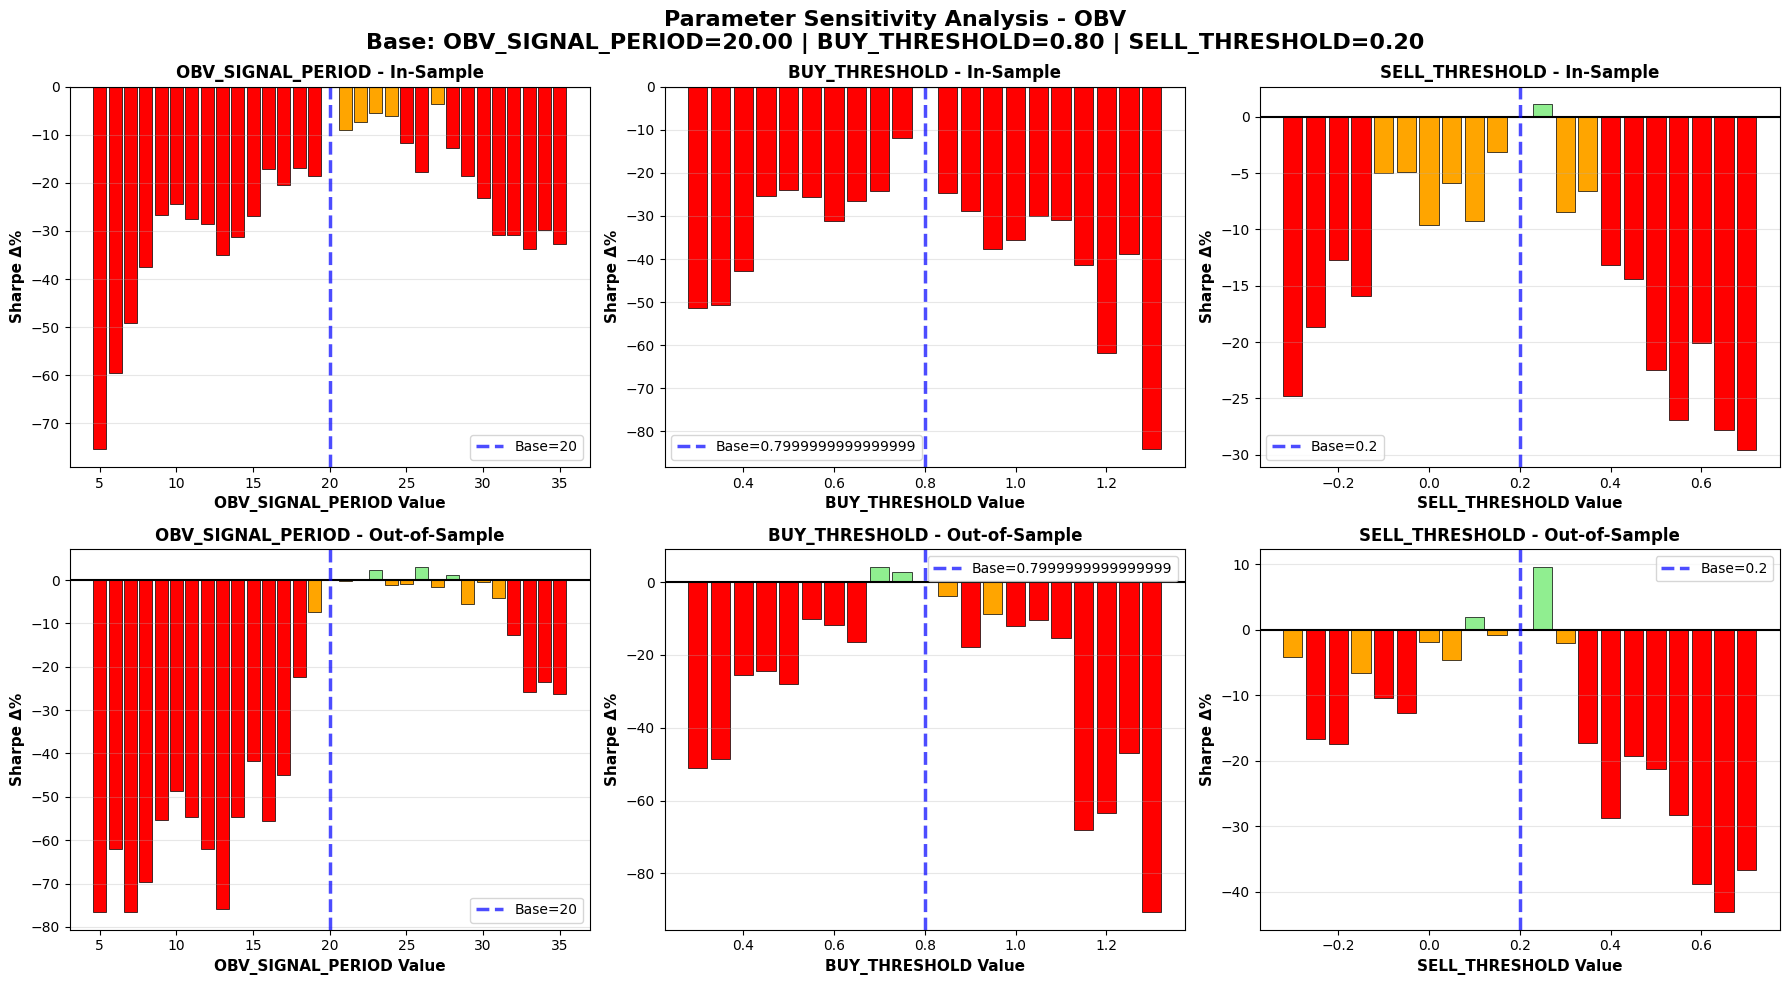

✓ Bar charts complete

📋 SENSITIVITY SUMMARY

Parameter       IS Range                  IS Max Δ%    OOS Range                 OOS Max Δ%   Sensitivity
----------------------------------------------------------------------------------------------------------------------------------
obv_signal_period 0.365 - 1.474                   75.3% 0.306 - 1.352             76.7%        ⚠️ VERY HIGH
buy_threshold   0.236 - 1.474                   84.0% 0.122 - 1.367             90.7%        ⚠️ VERY HIGH
sell_threshold  1.039 - 1.491                   29.5% 0.745 - 1.438             43.2%        ⚠️ HIGH

✅ Parameter Sensitivity Analysis Complete!

Sensitivity analysis complete!


In [ ]:
# PARAMETER SENSITIVITY ANALYSIS - HEATMAPS (IS & OOS SEPARATE)

if 'BEST_PARAMS' not in locals() or 'BEST_CHOICE' not in locals():
    print("⚠️ No best parameters configured. Run cells 11-12 first.")
else:
    print("=" * 130)
    print("🔬 PARAMETER SENSITIVITY ANALYSIS")
    print("=" * 130)
    
    # ========================================================================
    # STEP 1: USE BEST PARAMETERS AS BASELINE
    # ========================================================================
    
    param_cols = list(INDICATOR.params.keys())
    base_params = BEST_PARAMS.copy()
    
    print(f"\nIndicator: {INDICATOR.name}")
    print(f"Base Parameters: {BEST_PARAMS_STR}")
    print(f"Baseline Selection: {BEST_CHOICE}\n")
    
    # Get baseline metrics from cell 13
    if BEST_CHOICE == 'IS':
        base_is_sharpe = float(IS_METRICS['sharpe_ratio'])
        base_oos_sharpe = float(OOS_METRICS['sharpe_ratio'])
        print(f"Base IS Sharpe: {base_is_sharpe:.3f}")
        print(f"Base OOS Sharpe: {base_oos_sharpe:.3f}\n")
        has_oos = True
    elif BEST_CHOICE == 'OOS':
        base_is_sharpe = float(IS_METRICS['sharpe_ratio'])
        base_oos_sharpe = float(OOS_METRICS['sharpe_ratio'])
        print(f"Base IS Sharpe: {base_is_sharpe:.3f}")
        print(f"Base OOS Sharpe: {base_oos_sharpe:.3f}\n")
        has_oos = True
    
    # ========================================================================
    # STEP 2: CREATE SENSITIVITY RANGES
    # ========================================================================
    
    print("Creating sensitivity ranges (±15 around base)...")
    
    sensitivity_ranges = {}
    for param_name in param_cols:
        base_val = base_params[param_name]
        param_type = INDICATOR.params[param_name].param_type
        
        if param_type == float:
            step = INDICATOR.params[param_name].step / 2 if INDICATOR.params[param_name].step else 0.1
            min_val = float(base_val) - step * 10
            max_val = float(base_val) + step * 10
            sensitivity_ranges[param_name] = [round(v, 6) for v in np.arange(min_val, max_val + step / 2, step)]
        else:  # int
            step = 1
            min_val = max(2, int(base_val - 15))
            max_val = int(base_val + 15)
            sensitivity_ranges[param_name] = list(range(min_val, max_val + 1, step))
        print(f"  {param_name} ({param_type.__name__}): {base_val} (range: {min_val}-{max_val})")
    
    # ========================================================================
    # STEP 3: TEST SENSITIVITY ON TRAIN DATA (IN-SAMPLE)
    # ========================================================================
    
    print(f"\n🔄 Testing parameter variations on TRAIN period (in-sample)...")
    
    is_sensitivity_results = []
    
    for varying_param in param_cols:
        for param_value in sensitivity_ranges[varying_param]:
            test_params = base_params.copy()
            test_params[varying_param] = param_value
            
            indicators_is = INDICATOR.calc_func(train_close, **kwargs_is, **test_params)
            entries_is, exits_is = INDICATOR.signal_func(indicators_is, **test_params)
            
            entries_arr = entries_is.values.astype(bool) if isinstance(entries_is, pd.Series) else entries_is.astype(bool)
            exits_arr = exits_is.values.astype(bool) if isinstance(exits_is, pd.Series) else exits_is.astype(bool)
            
            pf_is = vbt.Portfolio.from_signals(
                close=train_close.values.astype(float),
                entries=entries_arr,
                exits=exits_arr,
                init_cash=100_000,
                fees=0.0005,
                slippage=0.0005,
                freq=FREQ
            )
            
            is_sharpe = float(pf_is.sharpe_ratio(freq=FREQ, year_freq=YEAR_FREQ))
            is_sharpe_delta = ((is_sharpe - base_is_sharpe) / abs(base_is_sharpe) * 100) if base_is_sharpe != 0 else 0
            
            is_sensitivity_results.append({
                'varying_param': varying_param,
                'param_value': param_value,
                'is_sharpe': is_sharpe,
                'is_sharpe_delta': is_sharpe_delta,
            })
    
    print(f"✓ {len(is_sensitivity_results)} IS tests complete")
    
    # ========================================================================
    # STEP 4: TEST SENSITIVITY ON VAL DATA (OUT-OF-SAMPLE)
    # ========================================================================
    
    oos_sensitivity_results = []
    
    if has_oos:
        print(f"🔄 Testing parameter variations on VAL period (out-of-sample)...")
        
        for varying_param in param_cols:
            for param_value in sensitivity_ranges[varying_param]:
                test_params = base_params.copy()
                test_params[varying_param] = param_value
                
                indicators_oos = INDICATOR.calc_func(val_close, **kwargs_oos, **test_params)
                entries_oos, exits_oos = INDICATOR.signal_func(indicators_oos, **test_params)
                
                entries_arr = entries_oos.values.astype(bool) if isinstance(entries_oos, pd.Series) else entries_oos.astype(bool)
                exits_arr = exits_oos.values.astype(bool) if isinstance(exits_oos, pd.Series) else exits_oos.astype(bool)
                
                pf_oos = vbt.Portfolio.from_signals(
                    close=val_close.values.astype(float),
                    entries=entries_arr,
                    exits=exits_arr,
                    init_cash=100_000,
                    fees=0.0005,
                    slippage=0.0005,
                    freq=FREQ
                )
                
                oos_sharpe = float(pf_oos.sharpe_ratio(freq=FREQ, year_freq=YEAR_FREQ))
                oos_sharpe_delta = ((oos_sharpe - base_oos_sharpe) / abs(base_oos_sharpe) * 100) if base_oos_sharpe != 0 else 0
                
                oos_sensitivity_results.append({
                    'varying_param': varying_param,
                    'param_value': param_value,
                    'oos_sharpe': oos_sharpe,
                    'oos_sharpe_delta': oos_sharpe_delta,
                })
        
        print(f"✓ {len(oos_sensitivity_results)} OOS tests complete\n")
    
    # ========================================================================
    # STEP 5: CREATE DATAFRAMES
    # ========================================================================
    
    is_df = pd.DataFrame(is_sensitivity_results)
    oos_df = pd.DataFrame(oos_sensitivity_results) if oos_sensitivity_results else None
    
    # ========================================================================
    # SECTION 1: BAR CHARTS - PARAMETER SENSITIVITY
    # ========================================================================
    
    print("Creating parameter sensitivity bar charts...")
    
    num_params = len(param_cols)
    num_rows = 2 if has_oos else 1
    
    fig, axes = plt.subplots(num_rows, num_params, figsize=(6*num_params, 5*num_rows))
    
    fig.suptitle(
        f'Parameter Sensitivity Analysis - {INDICATOR.name}\nBase: {BEST_PARAMS_STR}',
        fontsize=16, fontweight='bold'
    )
    
    # ====================================================================
    # IN-SAMPLE ROW (Row 0)
    # ====================================================================
    
    for col_idx, varying_param in enumerate(param_cols):
        ax = axes[0, col_idx] if num_params > 1 else axes[0]
        
        variations_is = is_df[is_df['varying_param'] == varying_param].sort_values('param_value')
        
        # Color scheme: red < -10%, orange -10 to 0%, lightgreen 0 to 10%, darkgreen >= 10%
        colors_is = [
            'red' if x < -10 
            else 'orange' if x < 0 
            else 'lightgreen' if x < 10 
            else 'darkgreen'
            for x in variations_is['is_sharpe_delta']
        ]
        
        # Calculate step size for bar width
        param_vals = variations_is['param_value'].values
        step = np.min(np.diff(np.sort(np.unique(param_vals)))) if len(np.unique(param_vals)) > 1 else 1
        width = step * 0.85  # 85% of step to leave gaps

        ax.bar(variations_is['param_value'], variations_is['is_sharpe_delta'], 
            width=width, color=colors_is, edgecolor='black', linewidth=0.5)
        
        ax.axhline(0, color='black', linewidth=1.5)
        ax.axvline(base_params[varying_param], color='blue', linestyle='--', 
                  linewidth=2.5, alpha=0.7, label=f'Base={base_params[varying_param]}')
        
        ax.set_xlabel(f'{varying_param.upper()} Value', fontsize=11, fontweight='bold')
        ax.set_ylabel('Sharpe Δ%', fontsize=11, fontweight='bold')
        ax.set_title(f'{varying_param.upper()} - In-Sample', fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        ax.legend(fontsize=10)
    
    # ====================================================================
    # OUT-OF-SAMPLE ROW (Row 1)
    # ====================================================================
    
    if has_oos and oos_df is not None and not oos_df.empty:
        for col_idx, varying_param in enumerate(param_cols):
            ax = axes[1, col_idx] if num_params > 1 else axes[1]
            
            variations_oos = oos_df[oos_df['varying_param'] == varying_param].sort_values('param_value')
            
            if not variations_oos.empty:
                # Color scheme: red < -10%, orange -10 to 0%, lightgreen 0 to 10%, darkgreen >= 10%
                colors_oos = [
                    'red' if x < -10 
                    else 'orange' if x < 0 
                    else 'lightgreen' if x < 10 
                    else 'darkgreen'
                    for x in variations_oos['oos_sharpe_delta']
                ]
                
                # Calculate step size for bar width
                param_vals = variations_oos['param_value'].values
                step = np.min(np.diff(np.sort(np.unique(param_vals)))) if len(np.unique(param_vals)) > 1 else 1
                width = step * 0.85  # 85% of step to leave gaps

                ax.bar(variations_oos['param_value'], variations_oos['oos_sharpe_delta'], 
                      width=width, color=colors_oos, edgecolor='black', linewidth=0.5)
                
                ax.axhline(0, color='black', linewidth=1.5)
                ax.axvline(base_params[varying_param], color='blue', linestyle='--', 
                          linewidth=2.5, alpha=0.7, label=f'Base={base_params[varying_param]}')
                
                ax.set_xlabel(f'{varying_param.upper()} Value', fontsize=11, fontweight='bold')
                ax.set_ylabel('Sharpe Δ%', fontsize=11, fontweight='bold')
                ax.set_title(f'{varying_param.upper()} - Out-of-Sample', fontsize=12, fontweight='bold')
                ax.grid(axis='y', alpha=0.3)
                ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Bar charts complete\n")
    
    # ========================================================================
    # SECTION 2: SENSITIVITY SUMMARY TABLE
    # ========================================================================
    
    print("=" * 130)
    print("📋 SENSITIVITY SUMMARY")
    print("=" * 130)
    
    print(f"\n{'Parameter':<15} {'IS Range':<25} {'IS Max Δ%':<12} {'OOS Range':<25} {'OOS Max Δ%':<12} {'Sensitivity'}")
    print("-" * 130)
    
    for varying_param in param_cols:
        variations_is = is_df[is_df['varying_param'] == varying_param]
        
        if variations_is.empty:
            continue
        
        is_range = f"{variations_is['is_sharpe'].min():.3f} - {variations_is['is_sharpe'].max():.3f}"
        is_max_delta = max(abs(variations_is['is_sharpe_delta'].min()), 
                          abs(variations_is['is_sharpe_delta'].max()))
        
        if has_oos and oos_df is not None:
            variations_oos = oos_df[oos_df['varying_param'] == varying_param]
            if not variations_oos.empty:
                oos_range = f"{variations_oos['oos_sharpe'].min():.3f} - {variations_oos['oos_sharpe'].max():.3f}"
                oos_max_delta = max(abs(variations_oos['oos_sharpe_delta'].min()), 
                                   abs(variations_oos['oos_sharpe_delta'].max()))
                oos_max_delta_str = f"{oos_max_delta:.1f}%"
            else:
                oos_range = "N/A"
                oos_max_delta_str = "N/A"
        else:
            oos_range = "N/A"
            oos_max_delta_str = "N/A"
        
        # Determine sensitivity
        if is_max_delta > 40:
            sensitivity = "⚠️ VERY HIGH"
        elif is_max_delta > 25:
            sensitivity = "⚠️ HIGH"
        elif is_max_delta > 10:
            sensitivity = "⚠️ MEDIUM"
        else:
            sensitivity = "✅ LOW"
        
        print(f"{varying_param:<15} {is_range:<25} {is_max_delta:>10.1f}% {oos_range:<25} {oos_max_delta_str:<12} {sensitivity}")
    
    print("\n" + "=" * 130)
    print("✅ Parameter Sensitivity Analysis Complete!")
    print("=" * 130)

print("\nSensitivity analysis complete!")